# 2차 Funnel — 3-모델 앙상블 (ensemble_2nd)

**대상**: Two-Stage Hybrid(분류×회귀) + 3-모델 다양성(LGBM/ET/ElasticNet) + LDS 가중치 + A4(proba→feature) + Isotonic Calibration.

**설계 문서**:
- [strategy_2nd_ensemble.md](strategy_2nd_ensemble.md) — 앙상블 코드 설계
- [strategy_2nd_preprocessing.md](strategy_2nd_preprocessing.md) — 전처리 모듈 설계

**흐름**: 환경 → 설정 → PP 축소 → 타깃 변환 → Main Optuna → Rerun+OOF → 진단 → 포지션 w → 모델 w → 최종 앙상블+로깅 → 시각화.

## 1. 환경 설정 + 데이터 로드

Colab/Local 자동 판별, gdown은 Colab에서만. 로컬 기준으로 작성하되 Colab 경로도 유지 (key는 필요 시 사용자가 기입).

In [1]:
# ============================================================
# 환경 설정 + 데이터 로드 (Colab / Local 공통)
# ============================================================
import os, sys

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/2_preprocessing/cleaning.py'):
        os.system('gdown 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip')
        os.system('unzip -qo /content/preprocessing.zip -d /content/project')
    if not os.path.exists('/content/project/3_modeling/modules/e2e_hpo.py'):
        os.system('gdown 1Vrn5LBl611rWbag7d09LZH68_lfpu6wP -O /content/modules.zip')
        os.makedirs('/content/project/3_modeling/modules', exist_ok=True)
        os.system('unzip -qo /content/modules.zip -d /content/project/3_modeling/modules')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# --- 기본 라이브러리 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 프로젝트 유틸 ---
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, POSITION_COL, OUTPUT_DIR
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import evaluate, rmse
from utils.experiment import log_experiment, check_exp_id, download_from_drive

# --- 3_modeling 모듈 (★ 2차 신규 import 포함) ---
sys.path.insert(0, os.path.join(PROJECT_ROOT, '3_modeling'))
from modules.e2e_hpo import (
    run_e2e_optimization_with_pp,
    rerun_best_trial_with_pp,
    add_rerun_to_study,               # ★ 2차
)
from modules.search_space import (
    PP_CLEAN_CANDIDATES,
    PP_OUTLIER_CANDIDATES,
    AGG_PRESETS,
    PP_ISO_ANOMALY_CANDIDATES,        # ★ 2차
    PP_LDS_CANDIDATES,                # ★ 2차
    PP_SCALE_CONFIG,                  # ★ 2차 (고정, 참고용)
    PP_BINARIZE_CONFIG,               # ★ 2차 (고정, 참고용)
)

# --- 데이터 로드 ---
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)

print(f'Feature 수: {len(feat_cols)}')
print(f'Die 수: train={len(xs_dict["train"]):,}, '
      f'val={len(xs_dict["validation"]):,}, '
      f'test={len(xs_dict["test"]):,}')
print(f'Unit 수: train={len(ys["train"]):,}, '
      f'val={len(ys["validation"]):,}, '
      f'test={len(ys["test"]):,}')

setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749
Feature 수: 1087
Die 수: train=104,988, val=34,996, test=34,996
Unit 수: train=26,247, val=8,749, test=8,749


## 2. 실험 설정

EXP_ID, USER, EXCLUDE_COLS 37개, pipeline_config, e2e_params(clf_models/reg_models list + calibration + add_clf_proba_to_reg), rerun_params, model_weight_params, position_weight_substudy, ensemble_save.

In [2]:
# ============================================================
# 실험 설정 (2차 Funnel — 3-모델 앙상블)
# ============================================================
#
# ★★★ 실험 전 체크리스트 — 아래 항목을 반드시 확인/수정 후 실행 ★★★
# ┌─────────────────────────────────────────────────────────┐
# │  1. EXP_ID      — 실험 고유 ID (중복 금지, 예: '1-001-002')     │
# │  2. EXP_MEMO    — 이번 실험 변경사항 메모                         │
# │  3. USER        — 본인 이니셜 ('jh', 'jw' 등)                  │
# │  4. n_trials    — 탐색 trial 수 (테스트=10, 본실험=100~200)      │
# │  5. n_folds     — main CV fold 수 (테스트=3, 본실험=5)           │
# │  6. sample_frac — 샘플링 비율 (테스트=0.2, 본실험=False로 전환)    │
# │  7. EVAL_TEST   — test 평가 (True=peek 위험, 최종 제출 전만 True) │
# └─────────────────────────────────────────────────────────┘

# ── 실험 식별 (매 실험마다 반드시 수정) ──
EXP_ID = '1-999-001'            # ★ 수정 필수: 실험 고유 ID. 2차는 '1-XXX-XXX' 시리즈
EXP_TYPE = 'ensemble + HPO'     # 실험 유형 (로그용, 자유 형식)
EXP_MEMO = '2차 funnel: 분류·회귀 3-모델 앙상블(LGBM+ET+선형), hybrid_scale 외부 1회, LDS, IsoForest score, Isotonic cal, A4'
                                # ★ 수정 필수: 이번 실험의 변경사항을 간결하게

# ── 평가 스위치 ──
EVAL_VAL  = True                # val RMSE 계산 여부 (항상 True 권장)
EVAL_TEST = True                # ★ test RMSE 계산 (True→peek 위험, 최종 제출 직전만 True 권장)

# ── 결과물 저장 스위치 ──
# True → val/test 예측 CSV + Optuna study pickle + OOF CSV 저장.
# Cell 8~10은 SAVE_OUTPUTS와 무관하게 in-memory로 동작 (CSV 읽기 없음).
SAVE_OUTPUTS = True

# ── 사용자 식별 ──
USER = 'jh'                     # ★ 수정 필수: 본인 이니셜 (DB 파일명에 포함)
assert USER, "USER를 지정해주세요 (예: USER = 'jw')"

# --- Google Drive 파일 ID (로컬 기준 — 필요시 본인이 입력) ---
CSV_GDRIVE_ID = ''              # ★ Colab 사용 시 공용 CSV ID 입력. 로컬이면 빈칸 유지

# ── 경로 (1차/2차 분리) ──
EXP_SUBDIR = '2차 실험'          # ★ 실험 차수에 맞게 변경 ('1차 실험' / '2차 실험')
DB_PATH = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'optuna_{USER}_{EXP_ID}.db')
OOF_DIR = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, 'oof', EXP_ID)
EXP_CSV_PATH = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, 'experiments.csv')
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)
os.makedirs(OOF_DIR, exist_ok=True)

LABEL_COL = 'label_bin'

# ── 타깃 변환 스위치 ──
TARGET_TRANSFORM = 'log1p'      # 'log1p' | 'yeo-johnson' | 'none'
CLIP_Y_EXTREME = True           # y_train 극단값(1.0) → 0.99분위로 클립

# --- 샘플링 ---
# ★ 본실험 시 use_sampling=False로 전환 (전체 데이터 사용)
# ★ 테스트/디버깅 시 True + sample_frac=0.2 (20%만 사용, 빠른 검증)
sampling_params = dict(
    use_sampling=True,          # ★ 본실험=False, 테스트=True
    sample_frac=0.05,            #    True일 때만 적용 — 사용 비율
)

# --- 웨이퍼맵 기반 사전 제외 feature (총 37개) ---
# - 35개: 1_eda/wafer_map_image/★분류완료/1_꼭빼야함/ 수동 분류
# - 2개 (★ 2026-04-16 2차 추가): 공간 패턴 feature 수동 선별 결과
#     · X1056: Ring 패턴, 기여 모호 → 제거
#     · X1072: X708과 radial 중복 → 제거
EXCLUDE_COLS = [
    'X124', 'X300', 'X301',
    'X443', 'X444', 'X447', 'X448', 'X449',
    'X451', 'X452', 'X455', 'X456', 'X457', 'X458', 'X459', 'X460',
    'X463', 'X464',
    'X503', 'X504', 'X505', 'X506',
    'X517',
    'X658', 'X659', 'X671', 'X672',
    'X674', 'X675', 'X676', 'X677',
    'X680', 'X687',
    'X1056',   # ★ 2차 추가: Ring 패턴, 기여 모호
    'X1072',   # ★ 2차 추가: X708과 radial 중복
    'X1074', 'X1078',
]

# ── 파이프라인 스위치 (2차는 Two-Stage ON + FS OFF) ──
# clf_filter=True → 회귀 학습 샘플을 clf_proba > threshold 기준으로 필터링.
#                   threshold는 Optuna가 clf_filter_threshold_range에서 탐색.
# clf_filter=False → 회귀는 y>0 정답 기준(oracle two-stage). threshold 안 쓰임.
pipeline_config = dict(
    input_level='die',          # 입력 데이터 레벨 ('die'=die-level, 'unit'=unit-level)
    run_clf=True,           # Two-Stage (P × R)
    clf_output='proba',         # 분류기 출력 형식 ('proba'=확률, 'binary'=0/1)
    clf_filter=True,        # ★ threshold 탐색 활성화 (False로 바꾸면 oracle two-stage)
    clf_optuna=True,            # True→clf HP를 Optuna 탐색, False→clf_fixed 사용
    run_fs=False,           # FS 활성화는 3차에서 (2차는 진단만)
    fs_optuna=False,            # True→FS top_k를 Optuna 탐색, False→top_k_fixed 사용
    reg_level='position',   # die-level + position OHE 병행
    reg_optuna=True,            # True→reg HP를 Optuna 탐색, False→reg_fixed 사용
    zero_clip=False,            # True→예측값 < threshold를 0으로 클립
)

# ── E2E HPO 설정 (★ 2차 신규: clf_models/reg_models/calibration/A4) ──
e2e_params = dict(
    # 3-모델 앙상블
    clf_models=['lgbm', 'et', 'logreg_enet'],
    reg_models=['lgbm', 'et', 'enet'],
    # Isotonic calibration — LGBM/ET에만 (LogReg는 자체 probabilistic)
    calibration={'method': 'isotonic', 'cv': 3, 'models': ['lgbm', 'et']},
    # A4: clf_proba_mean을 reg feature로 추가 (논문 2-1)
    add_clf_proba_to_reg=True,

    # ★ 실험 규모 조절 (테스트=작게, 본실험=크게)
    n_trials=1,           
    n_folds=3, 
    clf_early_stop=50,      #    early stopping patience (본실험=100)
    reg_early_stop=50,      #    early stopping patience (본실험=100)
    imbalance_method='scale_pos_weight',  # 클래스 불균형 대응 ('scale_pos_weight'/'smote'/None)
    top_k_range=(50, 500),      # FS top_k Optuna 탐색 범위 (run_fs=True일 때)
    top_k_fixed=200,            # FS top_k 고정값 (fs_optuna=False일 때)
    # ── clf_filter threshold 탐색 (clf_filter=True일 때만 Optuna 탐색, step=0.05 하드코딩됨) ──
    clf_filter_threshold_range=(0.05, 0.5),
    clf_filter_threshold_fixed=0.3,     # 폴백 값 (clf_filter=True & optuna ON이면 미사용)
    # ── zero_clip threshold (실험 결과 0.002 고정 확정) ──
    zero_clip_threshold_range=(0.002, 0.002),
    zero_clip_threshold_fixed=0.002,    # ★ 0.0 → 0.002 (rerun 일관성 유지)
    # clf_fixed / reg_fixed: 특정 하이퍼파라미터를 Optuna 탐색 대신 고정할 때 사용
    # 예: clf_fixed={'lgbm': {'n_estimators': 500}} → LGBM clf의 n_estimators를 500 고정
    clf_fixed={},
    reg_fixed={},
    pp_cache_size=10,       # 전처리 캐시 크기 (동일 PP 조합 재사용)
)

# ── Rerun 설정 (best trial 재학습) ──
# ★ 본실험 시 n_folds=5, early_stop=100~200 권장
rerun_params = dict(
    mode='kfold',               # 'kfold'=K-fold OOF, 'single'=단일 학습
    n_folds=4,              # rerun fold 수 (main보다 크게 권장)
    es_holdout=0.1,             # early stopping용 inner holdout 비율
    clf_early_stop=100,     # ★ 본실험=100~200
    reg_early_stop=100,     # ★ 본실험=100~200
    add_to_study=True,      # ★ 2차: add_rerun_to_study 호출
)

# ── Warm-start 설정 (★ 2차: 탐색 공간 크므로 top_k=50) ──
# DB가 비어있는 첫 실행에선 영향 없음. 재개 시에만 상위 K trial 재활용.
warm_start = dict(
    warm_start_top_k=50,        # 기존 DB에서 재활용할 상위 trial 수
    warm_start_enabled=True,    # True→기존 DB trial 재활용, False→새로 탐색
)

# ── 포지션 가중치 sub-study (★ 2차, Cell 8) ──
# ★ n_trials_per_model: 모델당 Optuna trial 수 (150이면 3모델×150=총 450 trial)
# ★ weight_range: 각 포지션 가중치 탐색 범위 (0.15~0.35, 균등=0.25)
# ★ weight_step: 탐색 해상도 (0.01 → 21단계)
position_weight_substudy = dict(
    n_trials_per_model=150,
    weight_range=(0.15, 0.35),
    weight_step=0.01,
    normalize='dirichlet',      # 가중치 정규화 방식 (합=1)
    per_model=True,             # True→모델마다 독립 w_pos 탐색
    save_path='position_weights_substudy.csv',  # OOF_DIR 하위에 저장
    save_top_k=20,              # 상위 K개 trial 결과 저장
)

# ── 모델 가중치 그리드서치 (★ 2차, Cell 9) ──
# ★ step: simplex 격자 해상도 (0.025 → ~861 조합, 0.05 → ~231 조합)
model_weight_params = dict(
    step=0.025,                     # ★ 정밀=0.025(861), 빠름=0.05(231)
    save_path='model_weights_grid.csv',   # OOF_DIR 하위에 저장
    save_top_k=20,              # 상위 K개 trial 결과 저장
)

# ── 최종 ensemble 저장 (★ 2차, Cell 10) ──
ensemble_save = dict(
    save_combined='combined_best.json',     # 최종 가중치·파라미터 JSON
    save_final_val='final_pred_val.csv',    # val unit-level 예측 (스키마 C)
    save_final_test='final_pred_test.csv',  # test unit-level 예측 (스키마 C)
    save_scaler='hybrid_scaler.pkl',        # HybridScaler pickle (3차 재사용)
)

# ── study user attrs (재현성용 메타데이터) ──
study_user_attrs = {
    'exp_id': EXP_ID, 'user': USER, 'exp_type': EXP_TYPE,
    'clf_models': e2e_params['clf_models'],
    'reg_models': e2e_params['reg_models'],
    'pp_scale_config': PP_SCALE_CONFIG,
    'pp_binarize_config': PP_BINARIZE_CONFIG,
    # ★ threshold 탐색 설정 로그 (재현성)
    'threshold_search': {
        'clf_filter_enabled':  pipeline_config['clf_filter'],
        'clf_filter_range':    list(e2e_params['clf_filter_threshold_range']),
        'clf_filter_step':     0.05,   # e2e_hpo.py에 하드코딩
        'clf_filter_fixed':    e2e_params['clf_filter_threshold_fixed'],
        'zero_clip_enabled':   pipeline_config['zero_clip'],
        'zero_clip_range':     list(e2e_params['zero_clip_threshold_range']),
        'zero_clip_fixed':     e2e_params['zero_clip_threshold_fixed'],
    },
}

# --- 설정 출력 ---
print(f'실험번호: {EXP_ID} | {EXP_TYPE}')
print(f'USER: {USER}')
print(f'CLF models: {e2e_params["clf_models"]}')
print(f'REG models: {e2e_params["reg_models"]}')
print(f'Calibration: {e2e_params["calibration"]}')
print(f'A4 (proba→reg feature): {e2e_params["add_clf_proba_to_reg"]}')
print(f'Trials: {e2e_params["n_trials"]} | Folds: main={e2e_params["n_folds"]}, rerun={rerun_params["n_folds"]}')
print(f'Warm-start top_k: {warm_start["warm_start_top_k"]}')
print(f'제외 컬럼: {len(EXCLUDE_COLS)}개 (35 기본 + 2 공간패턴 중복/모호)')
print(f'결과 저장: {"ON" if SAVE_OUTPUTS else "OFF"}')
print(f'타깃 변환: {TARGET_TRANSFORM} | CLIP_Y_EXTREME: {CLIP_Y_EXTREME}')
print(f'DB_PATH : {DB_PATH}')
print(f'OOF_DIR : {OOF_DIR}')
print(f'CSV_PATH: {EXP_CSV_PATH}')

# ── Threshold 탐색 설정 출력 ──
print(f'\n── Threshold 탐색 ──')
_clf_on = pipeline_config["clf_filter"]
print(f'  clf_filter   : {"ON (Optuna 탐색)" if _clf_on else "OFF (oracle two-stage)"}')
print(f'                 range={e2e_params["clf_filter_threshold_range"]}, step=0.05, '
      f'fixed={e2e_params["clf_filter_threshold_fixed"]}')
_zc_lo, _zc_hi = e2e_params["zero_clip_threshold_range"]
_zc_search = pipeline_config["zero_clip"] and (_zc_lo != _zc_hi)
print(f'  zero_clip    : {"ON" if pipeline_config["zero_clip"] else "OFF"} '
      f'({"탐색" if _zc_search else "고정"})')
print(f'                 range={e2e_params["zero_clip_threshold_range"]}, '
      f'fixed={e2e_params["zero_clip_threshold_fixed"]}')

print(f'\n── Pipeline Config ──')
for k, v in pipeline_config.items():
    print(f'  {k}: {v}')
print(f'\n── HybridScaler 고정 설정 ──')
print(f'  {PP_SCALE_CONFIG}')
print(f'  Binarize: {PP_BINARIZE_CONFIG}')

# CSV만 Drive에서 내려받기 (빈 ID면 스킵)
if CSV_GDRIVE_ID:
    download_from_drive(csv_gdrive_id=CSV_GDRIVE_ID)
check_exp_id(EXP_ID)

실험번호: 1-999-001 | ensemble + HPO
USER: jh
CLF models: ['lgbm', 'et', 'logreg_enet']
REG models: ['lgbm', 'et', 'enet']
Calibration: {'method': 'isotonic', 'cv': 3, 'models': ['lgbm', 'et']}
A4 (proba→reg feature): True
Trials: 1 | Folds: main=3, rerun=4
Warm-start top_k: 50
제외 컬럼: 37개 (35 기본 + 2 공간패턴 중복/모호)
결과 저장: ON
타깃 변환: log1p | CLIP_Y_EXTREME: True
DB_PATH : c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\optuna_jh_1-999-001.db
OOF_DIR : c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001
CSV_PATH: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\experiments.csv

── Threshold 탐색 ──
  clf_filter   : ON (Optuna 탐색)
                 range=(0.05, 0.5), step=0.05, fixed=0.3
  zero_clip    : OFF (고정)
                 range=(0.002, 0.002), fixed=0.002

── Pipeline Config ──
  input_level: die
  run_clf: True
  clf_output: proba
  clf_filter: True
  clf_optuna: True
  run_fs: False
  fs_optuna: False
  reg_level: position
  reg_optuna: Tru

## 3. 전처리 Search Space 확인 / 축소

1차 `optuna_merged.db` 결과 기반으로 `PP_CLEAN_CANDIDATES` / `PP_OUTLIER_CANDIDATES` / `PP_ISO_ANOMALY_CANDIDATES` / `PP_LDS_CANDIDATES` 축소. 사용자 편집 영역.

In [3]:
# ============================================================
# 전처리 Search Space 확인 / 축소 (사용자 편집 영역)
# ============================================================
# 1차 optuna viewer 결과를 참고해 각 candidate 리스트에서 원소를 제거한다.
# IsoForest / LDS candidates는 2차 first-run이므로 MD 스펙대로 전 범위 유지.

# ── 현재 전처리 search space 확인 ──
print('── PP_CLEAN_CANDIDATES ──')
for k, v in PP_CLEAN_CANDIDATES.items():
    print(f'  {k}: {v}')

print('\n── PP_OUTLIER_CANDIDATES ──')
for k, v in PP_OUTLIER_CANDIDATES.items():
    print(f'  {k}: {v}')

print('\n── PP_ISO_ANOMALY_CANDIDATES (★ 2차 신규) ──')
for k, v in PP_ISO_ANOMALY_CANDIDATES.items():
    print(f'  {k}: {v}')

print('\n── PP_LDS_CANDIDATES (★ 2차 신규) ──')
for k, v in PP_LDS_CANDIDATES.items():
    print(f'  {k}: {v}')

print('\n── AGG_PRESETS ──')
for i, preset in enumerate(AGG_PRESETS):
    print(f'  [{i}] {preset}')


# ──────────────────────────────────────────────────────────────
# 범위 축소 (필요 시 아래에서 수정)
# ──────────────────────────────────────────────────────────────
# 1차 best에서 imputation=spatial, outlier=winsorize가 우세했음 → 해당 방향 유지
PP_CLEAN_CANDIDATES['imputation_method'] = ['spatial']
PP_OUTLIER_CANDIDATES['method']          = ['winsorize']
# 추가 축소 예시 (주석 해제해서 사용):
# PP_CLEAN_CANDIDATES['corr_threshold'] = [0.94]
# PP_ISO_ANOMALY_CANDIDATES['iso_n_estimators'] = [100]


# ── 탐색 공간 크기 추정 (grid 전개 시) ──
from functools import reduce
import operator
space_sizes = (
    [len(v) for v in PP_CLEAN_CANDIDATES.values()]
    + [len(v) for v in PP_OUTLIER_CANDIDATES.values()]
    + [len(v) for v in PP_ISO_ANOMALY_CANDIDATES.values()]
    + [len(v) for v in PP_LDS_CANDIDATES.values()]
    + [len(AGG_PRESETS)]
)
total_grid = reduce(operator.mul, space_sizes, 1)
print(f'\n전처리 search space 크기 (grid): {total_grid:,}')
print(f'(Optuna는 TPE로 효율 탐색 — 실제 n_trials={e2e_params["n_trials"]}로 충분)')

── PP_CLEAN_CANDIDATES ──
  const_threshold: [1e-06]
  missing_threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
  remove_duplicates: [True]
  corr_threshold: [0.9, 0.94, 0.98]
  corr_keep_by: ['std', 'target_corr']
  add_indicator: [True, False]
  indicator_threshold: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]
  imputation_method: ['spatial']
  knn_neighbors: [3, 5, 10]
  spatial_max_dist: [1.0, 2.0, 3.0, 4.0, 5.0]
  post_impute_corr_threshold: [0.97, 0.98, 0.99]
  post_impute_corr_keep_by: ['std', 'target_corr']

── PP_OUTLIER_CANDIDATES ──
  method: ['winsorize']
  lower_pct: [0.0]
  upper_pct: [0.99]
  iqr_multiplier: [1.5, 3.0, 5.0]

── PP_ISO_ANOMALY_CANDIDATES (★ 2차 신규) ──
  iso_enabled: [True, False]
  iso_contamination: [0.05, 0.1, 'auto']
  iso_n_estimators: [100, 200]

── PP_LDS_CANDIDATES (★ 2차 신규) ──
  lds_enabled: [True, False]
  lds_sigma: [0.005, 0.01, 0.02]
  lds_max_weight: [5.0, 10.0]

── AGG_PRESETS ──
  [0] ['mean', 'std', 'range', 'min', 'max', 'median']
  [1] ['me

## 4. 타겟 변환 + 분포 시각화

baseline Cell 8 패턴 그대로. `log1p` + `CLIP_Y_EXTREME` + 2×3 분포 히스토그램.

[CLIP_Y_EXTREME] 1.0 → 0.097417 클립 | 클립된 샘플: 1개
[log1p] target_transform_fn 등록 (ys_input은 원본 유지)


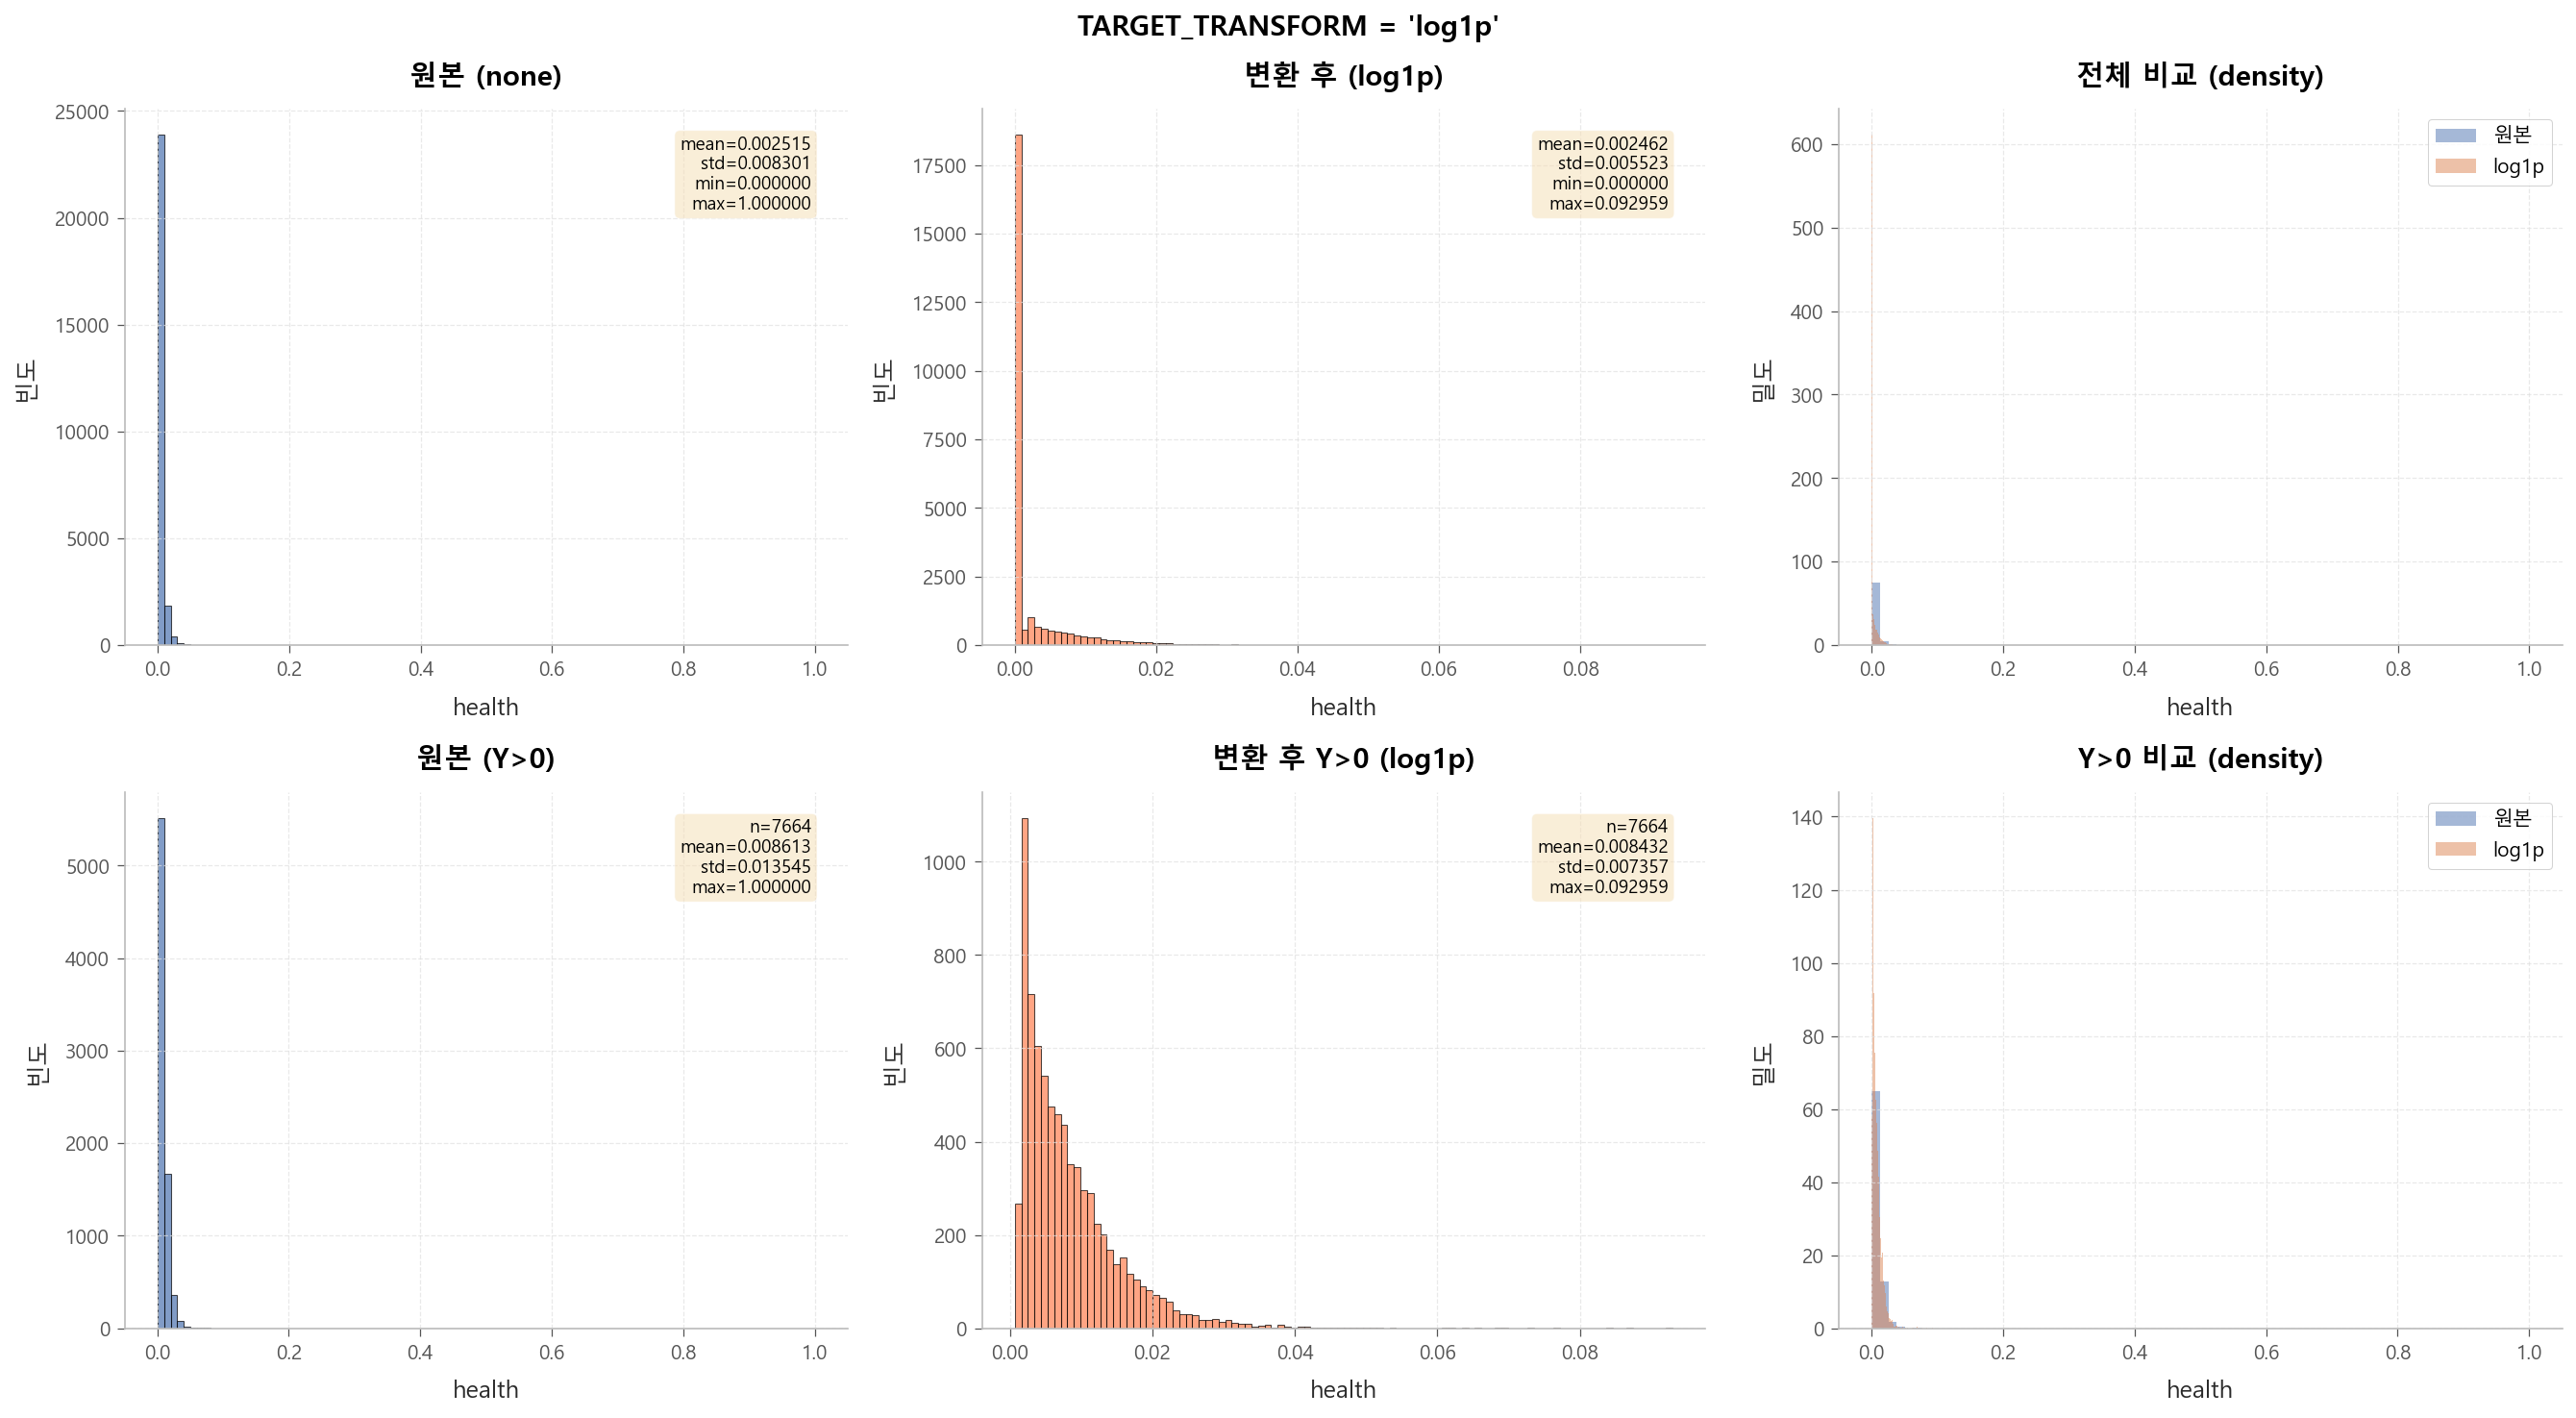

In [4]:
# ============================================================
# 타깃 변환 + 분포 시각화 (baseline cell 8과 동일)
# ============================================================
# ys_input은 항상 **원본 스케일**을 유지한다 (train y만 CLIP_Y_EXTREME 적용).
# transform/inverse는 e2e 함수 내부에서 reg fit 직전/예측 직후에만 일어나며,
# zero_clip/RMSE/val_rmse 등 모든 후처리는 원본 스케일에서 계산된다.
target_transformer  = None
target_transform_fn = None
target_inverse_fn   = None
ys_input = {k: v.copy() for k, v in ys.items()}

# ── y_train 극단값 클립 ──
if CLIP_Y_EXTREME:
    _train_y_raw = ys_input['train'][TARGET_COL]
    _second_max  = _train_y_raw[_train_y_raw < _train_y_raw.max()].max()
    ys_input['train'][TARGET_COL] = _train_y_raw.clip(upper=_second_max)
    print(f'[CLIP_Y_EXTREME] 1.0 → {_second_max:.6f} 클립 | '
          f'클립된 샘플: {(_train_y_raw >= 1.0).sum()}개')

# ── 변환 함수 등록 ──
if TARGET_TRANSFORM == 'log1p':
    target_transform_fn = lambda y: np.log1p(np.asarray(y))
    target_inverse_fn   = lambda y: np.clip(np.expm1(np.asarray(y)), 0.0, None)
    print('[log1p] target_transform_fn 등록 (ys_input은 원본 유지)')

elif TARGET_TRANSFORM == 'yeo-johnson':
    from sklearn.preprocessing import PowerTransformer
    target_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    _train_y_clipped = ys_input['train'][TARGET_COL].values.reshape(-1, 1)
    target_transformer.fit(_train_y_clipped)
    _tt_vals = target_transformer.transform(_train_y_clipped).ravel()
    _tt_min, _tt_max = float(_tt_vals.min()), float(_tt_vals.max())

    def target_transform_fn(y):
        return target_transformer.transform(np.asarray(y).reshape(-1, 1)).ravel()

    def target_inverse_fn(y):
        y_clip = np.clip(np.asarray(y), _tt_min, _tt_max)
        out = target_transformer.inverse_transform(y_clip.reshape(-1, 1)).ravel()
        return np.nan_to_num(np.clip(out, 0.0, None), nan=0.0, posinf=0.0, neginf=0.0)

    print(f'[yeo-johnson] target_transform_fn 등록 (train y 범위: [{_tt_min:.6f}, {_tt_max:.6f}])')

else:  # 'none'
    print('[none] target 변환 없음')


# ── 타깃 변환 전후 분포 시각화 ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

y_orig = ys['train'][TARGET_COL]
if target_transform_fn is not None:
    y_trans = pd.Series(
        target_transform_fn(ys_input['train'][TARGET_COL].values),
        index=ys_input['train'].index,
    )
else:
    y_trans = ys_input['train'][TARGET_COL]
y_orig_nz  = y_orig[y_orig > 0]
y_trans_nz = y_trans[y_trans != y_trans.min()]

axes[0, 0].hist(y_orig, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('원본 (none)')
axes[0, 0].text(0.95, 0.95,
                f'mean={y_orig.mean():.6f}\nstd={y_orig.std():.6f}\n'
                f'min={y_orig.min():.6f}\nmax={y_orig.max():.6f}',
                transform=axes[0, 0].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 1].hist(y_trans, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title(f'변환 후 ({TARGET_TRANSFORM})')
axes[0, 1].text(0.95, 0.95,
                f'mean={y_trans.mean():.6f}\nstd={y_trans.std():.6f}\n'
                f'min={y_trans.min():.6f}\nmax={y_trans.max():.6f}',
                transform=axes[0, 1].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 2].hist(y_orig,  bins=80, alpha=0.5, label='원본', density=True)
axes[0, 2].hist(y_trans, bins=80, alpha=0.5, label=f'{TARGET_TRANSFORM}', density=True)
axes[0, 2].set_title('전체 비교 (density)')
axes[0, 2].legend()

axes[1, 0].hist(y_orig_nz, bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('원본 (Y>0)')
axes[1, 0].text(0.95, 0.95,
                f'n={len(y_orig_nz)}\nmean={y_orig_nz.mean():.6f}\n'
                f'std={y_orig_nz.std():.6f}\nmax={y_orig_nz.max():.6f}',
                transform=axes[1, 0].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1, 1].hist(y_trans_nz, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title(f'변환 후 Y>0 ({TARGET_TRANSFORM})')
axes[1, 1].text(0.95, 0.95,
                f'n={len(y_trans_nz)}\nmean={y_trans_nz.mean():.6f}\n'
                f'std={y_trans_nz.std():.6f}\nmax={y_trans_nz.max():.6f}',
                transform=axes[1, 1].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1, 2].hist(y_orig_nz,  bins=80, alpha=0.5, label='원본', density=True)
axes[1, 2].hist(y_trans_nz, bins=80, alpha=0.5, label=f'{TARGET_TRANSFORM}', density=True)
axes[1, 2].set_title('Y>0 비교 (density)')
axes[1, 2].legend()

for ax in axes.flat:
    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel('빈도' if ax in axes[:, :2].flat else '밀도')

fig.suptitle(f'TARGET_TRANSFORM = {TARGET_TRANSFORM!r}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Main Optuna 실행

옵션 A: 1 study, trial=6 모델 동시 학습. warm_start 명시 전달.

In [5]:
# ============================================================
# Main Optuna 실행 (★ 옵션 A — 1 study, trial당 6개 모델 동시 학습)
# ============================================================
# trial 1회 ≈ 전처리(cached) + 3 clf × n_folds + 3 reg × n_folds
# trial objective = ensemble OOF RMSE (단순 평균 앙상블 기준)

result = run_e2e_optimization_with_pp(
    xs=xs, xs_dict=xs_dict, ys=ys_input, feat_cols=feat_cols,
    pipeline_config=pipeline_config,
    label_col=LABEL_COL,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    # ── E2E HPO 공통 인자 + ★ 2차 신규 (clf_models/reg_models/calibration/A4) ──
    **e2e_params,
    # ── 타깃 변환 콜백 ──
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
    # ── SQLite / warm start ──
    exp_id=EXP_ID,
    db_path=DB_PATH,
    study_user_attrs=study_user_attrs,
    warm_start_top_k=warm_start['warm_start_top_k'],
    warm_start_enabled=warm_start['warm_start_enabled'],
)

study       = result['study']
best_params = result['best_params']
best_value  = result['best_value']

print(f'\n── Main Optuna 완료 ──')
print(f'  best_value (OOF RMSE): {best_value:.6f}')
print(f'  n_trials             : {len(study.trials)}')
print(f'  study.best_trial.user_attrs keys:')
for k in sorted(study.best_trial.user_attrs.keys()):
    v = study.best_trial.user_attrs[k]
    if isinstance(v, (dict, list)) and len(str(v)) > 120:
        print(f'{k}: {type(v).__name__} (len={len(v)})')
    else:
        print(f'{k}: {v}')

[Warm Start] 기존 17개 완료 trial을 TPE posterior로 재활용 (enqueue 재실행 X, warm_start_top_k=50는 deprecated no-op)


  0%|          | 0/1 [00:00<?, ?it/s]


E2E + Preprocessing HPO 완료 (1 trials)  [2026-04-17 14:13]
Storage       : c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\optuna_jh_1-999-001.db
Study         : 1-999-001
Total trials  : 18 (기존 17 + 신규 1)
PP cache      : 1/10 entries (unique combos)
Best OOF RMSE : 0.005617
Val RMSE (ref): 0.005830
N Features    : clean=591  selected=596
Best agg_funcs: ['mean', 'std', 'range', 'min', 'max', 'median']
CLF filter th : 0.350
Best trial at : 2026-04-17 12:59

── Main Optuna 완료 ──
  best_value (OOF RMSE): 0.005617
  n_trials             : 21
  study.best_trial.user_attrs keys:
agg_funcs: ['mean', 'std', 'range', 'min', 'max', 'median']
cleaning_args: dict (len=12)
clf_train_oof_auc: 0.6135707024068427
clf_val_ap: 0.34465714558691696
clf_val_auc: 0.594642211435598
clf_val_f1: 0.024160060400151
clf_val_precision: 0.3404255319148936
clf_val_recall: 0.012524461839530333
iso_enabled: True
lds_enabled: True
n_feat_clean: 591
n_feat_selected: 596
outlier_args: {'method': 'winsorize

## 6. Rerun (kfold=5) + die-level OOF CSV 저장 + Study 기록

Best params로 kfold=5 재학습 → 7개 OOF CSV 저장 (meta 1 + clf×3 + reg×3) → `add_rerun_to_study`로 같은 DB에 append.

In [6]:
# ============================================================
# Rerun (kfold=5) + die-level OOF CSV 7개 저장 + Study 기록
# ============================================================
# - mode='kfold'로 best params 재학습 → 모델·예측·OOF 추출
# - save_per_model_oof=True → oof_meta.csv + oof_clf_{m}.csv×3 + oof_reg_{m}.csv×3
# - add_rerun_to_study → 같은 DB에 FrozenTrial append (is_rerun=True)

final = rerun_best_trial_with_pp(
    xs=xs, xs_dict=xs_dict, ys=ys_input, feat_cols=feat_cols,
    best_params=best_params,
    pipeline_config=pipeline_config,
    label_col=LABEL_COL,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    # ── rerun 공통 ──
    mode=rerun_params['mode'],
    n_folds=rerun_params['n_folds'],
    es_holdout=rerun_params['es_holdout'],
    clf_early_stop=rerun_params['clf_early_stop'],
    reg_early_stop=rerun_params['reg_early_stop'],
    # ── ★ 2차 신규 ──
    clf_models=e2e_params['clf_models'],
    reg_models=e2e_params['reg_models'],
    calibration=e2e_params['calibration'],
    add_clf_proba_to_reg=e2e_params['add_clf_proba_to_reg'],
    save_per_model_oof=SAVE_OUTPUTS,
    oof_dir=OOF_DIR,
    # ── 고정 값 전달 (best_params에 없으면 폴백) ──
    top_k_fixed=e2e_params['top_k_fixed'],
    clf_filter_threshold_fixed=e2e_params['clf_filter_threshold_fixed'],
    zero_clip_threshold_fixed=e2e_params['zero_clip_threshold_fixed'],
    clf_fixed=e2e_params['clf_fixed'],
    reg_fixed=e2e_params['reg_fixed'],
    # ── 타깃 변환 ──
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
)

# 주요 결과 요약
print(f'\n── Rerun 완료 ──')
print(f'  OOF RMSE      : {final["oof_rmse"]:.6f}')
print(f'  Val RMSE      : {final["val_rmse"]:.6f}' if final.get('val_rmse') is not None else '  Val RMSE      : N/A')
print(f'  selected_cols : {len(final["selected_cols"])} cols')
print(f'  scaler        : {type(final["scaler"]).__name__}')
print(f'  sample_weight : {"die-level len=" + str(len(final["sample_weight"])) if final["sample_weight"] is not None else "None"}')
print(f'  iso_args      : {final["iso_args"]}')
print(f'  lds_args      : {final["lds_args"]}')

# 모델별 단독 RMSE (앙상블과 비교)
print(f'\n  per_model val RMSE :')
for m, v in (final.get('per_model_val_rmse') or {}).items():
    print(f'    {m:12s}: {v:.6f}' if v is not None else f'    {m:12s}: N/A')
print(f'  per_model test RMSE:')
for m, v in (final.get('per_model_test_rmse') or {}).items():
    print(f'    {m:12s}: {v:.6f}' if v is not None else f'    {m:12s}: N/A')

# fold 모델 수 확인 (Cell 7 진단 셀에서 사용)
print(f'\n  per_model_fold_models:')
for m, models in (final.get('per_model_fold_models') or {}).items():
    print(f'    {m:5s}: {len(models)} fold models ({type(models[0]).__name__ if models else "empty"})')

# OOF 파일
oof_files = final.get('oof_files') or []
print(f'\n  OOF CSV files ({len(oof_files)}):')
for f in oof_files:
    print(f'    {os.path.basename(f)}')


# ── Study에 rerun trial append ──
# [P1-1] main study objective는 OOF RMSE (e2e_hpo.py)이므로 rerun value도 OOF로 통일.
#        viewer에서 main trial ↔ rerun trial을 같은 axis로 비교 가능.
#        val RMSE는 user_attrs로만 기록.
if rerun_params.get('add_to_study', True):
    add_rerun_to_study(
        study, best_params, rerun_value=float(final['oof_rmse']),
        user_attrs={
            'is_rerun': True,
            'rerun_mode': rerun_params['mode'],
            'rerun_n_folds': rerun_params['n_folds'],
            'rerun_oof_rmse': float(final['oof_rmse']),
            'rerun_val_rmse': float(final['val_rmse']) if final.get('val_rmse') else None,
        },
    )

Rerun preprocessing: cleaning=12 args, outlier method=winsorize, iso_enabled=True, lds_enabled=True, agg_funcs=['mean', 'std', 'range', 'min', 'max', 'median']
클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=60%
  제거: 5개, 잔여: 977개
    컬럼: 982 → 977 (5개 제거)
    DataFrame: (104988, 981)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 951개
    컬럼: 977 → 951 (26개 제거)
    DataFrame: (104988, 955)

[고상관 제거] threshold=0.9, keep_by=std (std)
  제거: 339개, 잔여: 612개
    컬럼: 951 → 612 (339개 제거)
    DataFrame: (104988, 616)

[결측 indicator] 4개 컬럼 추가 (결측률 >= 25%)
[공간 보간 imputation] 총 결측: 592,729
  train-only 모드: train 104,988 / 전체 174,980 행
  1단계 (공간 보간, dist<=3.0): 114,385개 채움 → 잔여: 478,344
  2단계 (lot 평균, train 기준): 397,148개 채움 → 잔여: 81,196
  3단계 (train 전체 평균): 81,196개 채움 → 잔여: 0

  [요약] 592,729 → 공간(114,385) → lot(397,148) → 전체(81,196) → 잔여(0)

[고상관 제거] threshold=0.97, keep_by=target_corr (|targe

## 6.5 성능 지표 저장 (metrics.csv)

clf AUC/AP/F1 (train/val/test) + reg per-model RMSE (val/test) + ensemble RMSE. 전부 `final` in-memory에서 계산.

In [7]:
# ============================================================
# 성능 지표 집약 저장 — metrics.csv (in-memory 전용)
# ============================================================
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

def _get_die_or_unit(split):
    """die-level unit_data 우선, 없으면 unit-level fallback."""
    ud_die = final.get('unit_data_die')
    if ud_die is not None:
        return ud_die[split]
    return final['unit_data'][split]

metrics_rows = []

# ── clf 지표: soft-voted proba (final['unit_data'][split]['clf_proba_mean']) ──
has_clf_proba = 'clf_proba_mean' in _get_die_or_unit('train').columns

if has_clf_proba:
    for split_name in ['train', 'val', 'test']:
        d = _get_die_or_unit(split_name)
        y_bin = (d[TARGET_COL] > 0).astype(int).values
        proba = d['clf_proba_mean'].values
        pred_bin = (proba >= 0.5).astype(int)
        metrics_rows.append({'stage': 'clf', 'model': 'soft_vote', 'split': split_name,
                             'metric': 'auc', 'value': roc_auc_score(y_bin, proba)})
        metrics_rows.append({'stage': 'clf', 'model': 'soft_vote', 'split': split_name,
                             'metric': 'ap', 'value': average_precision_score(y_bin, proba)})
        metrics_rows.append({'stage': 'clf', 'model': 'soft_vote', 'split': split_name,
                             'metric': 'f1', 'value': f1_score(y_bin, pred_bin, zero_division=0)})
        metrics_rows.append({'stage': 'clf', 'model': 'soft_vote', 'split': split_name,
                             'metric': 'precision', 'value': precision_score(y_bin, pred_bin, zero_division=0)})
        metrics_rows.append({'stage': 'clf', 'model': 'soft_vote', 'split': split_name,
                             'metric': 'recall', 'value': recall_score(y_bin, pred_bin, zero_division=0)})
else:
    print("⚠ clf_proba_mean 컬럼 없음 — clf 지표 스킵 (clf가 실행되지 않았거나 결과가 None)")

# ── clf 지표: per-model ──
if has_clf_proba:
    for m in e2e_params.get('clf_models', []):
        if m not in (final.get('per_model_clf') or {}):
            continue
        for split_name in ['train', 'val', 'test']:
            d = _get_die_or_unit(split_name)
            y_bin = (d[TARGET_COL] > 0).astype(int).values
            proba_arr = np.concatenate([
                final['per_model_clf'][m][pos][f'{split_name}_proba']
                for pos in sorted(final['per_model_clf'][m].keys())
            ])
            metrics_rows.append({'stage': 'clf', 'model': m, 'split': split_name,
                                 'metric': 'auc', 'value': roc_auc_score(y_bin, proba_arr)})

# ── reg 지표: per-model RMSE (val/test만 기존에 계산됨) ──
for m in e2e_params.get('reg_models', []):
    val_r = (final.get('per_model_val_rmse') or {}).get(m)
    test_r = (final.get('per_model_test_rmse') or {}).get(m)
    if val_r is not None:
        metrics_rows.append({'stage': 'reg', 'model': m, 'split': 'val',
                             'metric': 'rmse', 'value': val_r})
    if test_r is not None:
        metrics_rows.append({'stage': 'reg', 'model': m, 'split': 'test',
                             'metric': 'rmse', 'value': test_r})

# ── reg 지표: ensemble RMSE ──
metrics_rows.append({'stage': 'reg', 'model': 'ensemble', 'split': 'oof',
                     'metric': 'rmse', 'value': final['oof_rmse']})
if final.get('val_rmse') is not None:
    metrics_rows.append({'stage': 'reg', 'model': 'ensemble', 'split': 'val',
                         'metric': 'rmse', 'value': final['val_rmse']})

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string(index=False))

if SAVE_OUTPUTS:
    mpath = os.path.join(OOF_DIR, 'metrics.csv')
    metrics_df.to_csv(mpath, index=False)
    print(f'\n저장: {mpath}')

stage       model split    metric    value
  clf   soft_vote train       auc 0.591495
  clf   soft_vote train        ap 0.382119
  clf   soft_vote train        f1 0.167554
  clf   soft_vote train precision 0.407059
  clf   soft_vote train    recall 0.105488
  clf   soft_vote   val       auc 0.568264
  clf   soft_vote   val        ap 0.330541
  clf   soft_vote   val        f1 0.096828
  clf   soft_vote   val precision 0.339812
  clf   soft_vote   val    recall 0.056458
  clf   soft_vote  test       auc 0.575582
  clf   soft_vote  test        ap 0.343784
  clf   soft_vote  test        f1 0.118682
  clf   soft_vote  test precision 0.390924
  clf   soft_vote  test    recall 0.069961
  clf        lgbm train       auc 0.557609
  clf        lgbm   val       auc 0.549196
  clf        lgbm  test       auc 0.549317
  clf          et train       auc 0.619497
  clf          et   val       auc 0.580276
  clf          et  test       auc 0.586117
  clf logreg_enet train       auc 0.557717
  clf logre

## 7. Feature 제거 후보 진단

3-모델(LGBM gain / ET impurity / ElasticNet `|coef|`)의 "무관" 판정 교집합 + Top-20 bar + 분포 histogram.

3-모델 모두 무관 판정: 0개 feature

LGBM 하위 10% (gain < 0.0000): 0
ET   하위 10% (impurity < 0.0005): 60
ENet coef ≈ 0                          : 402


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

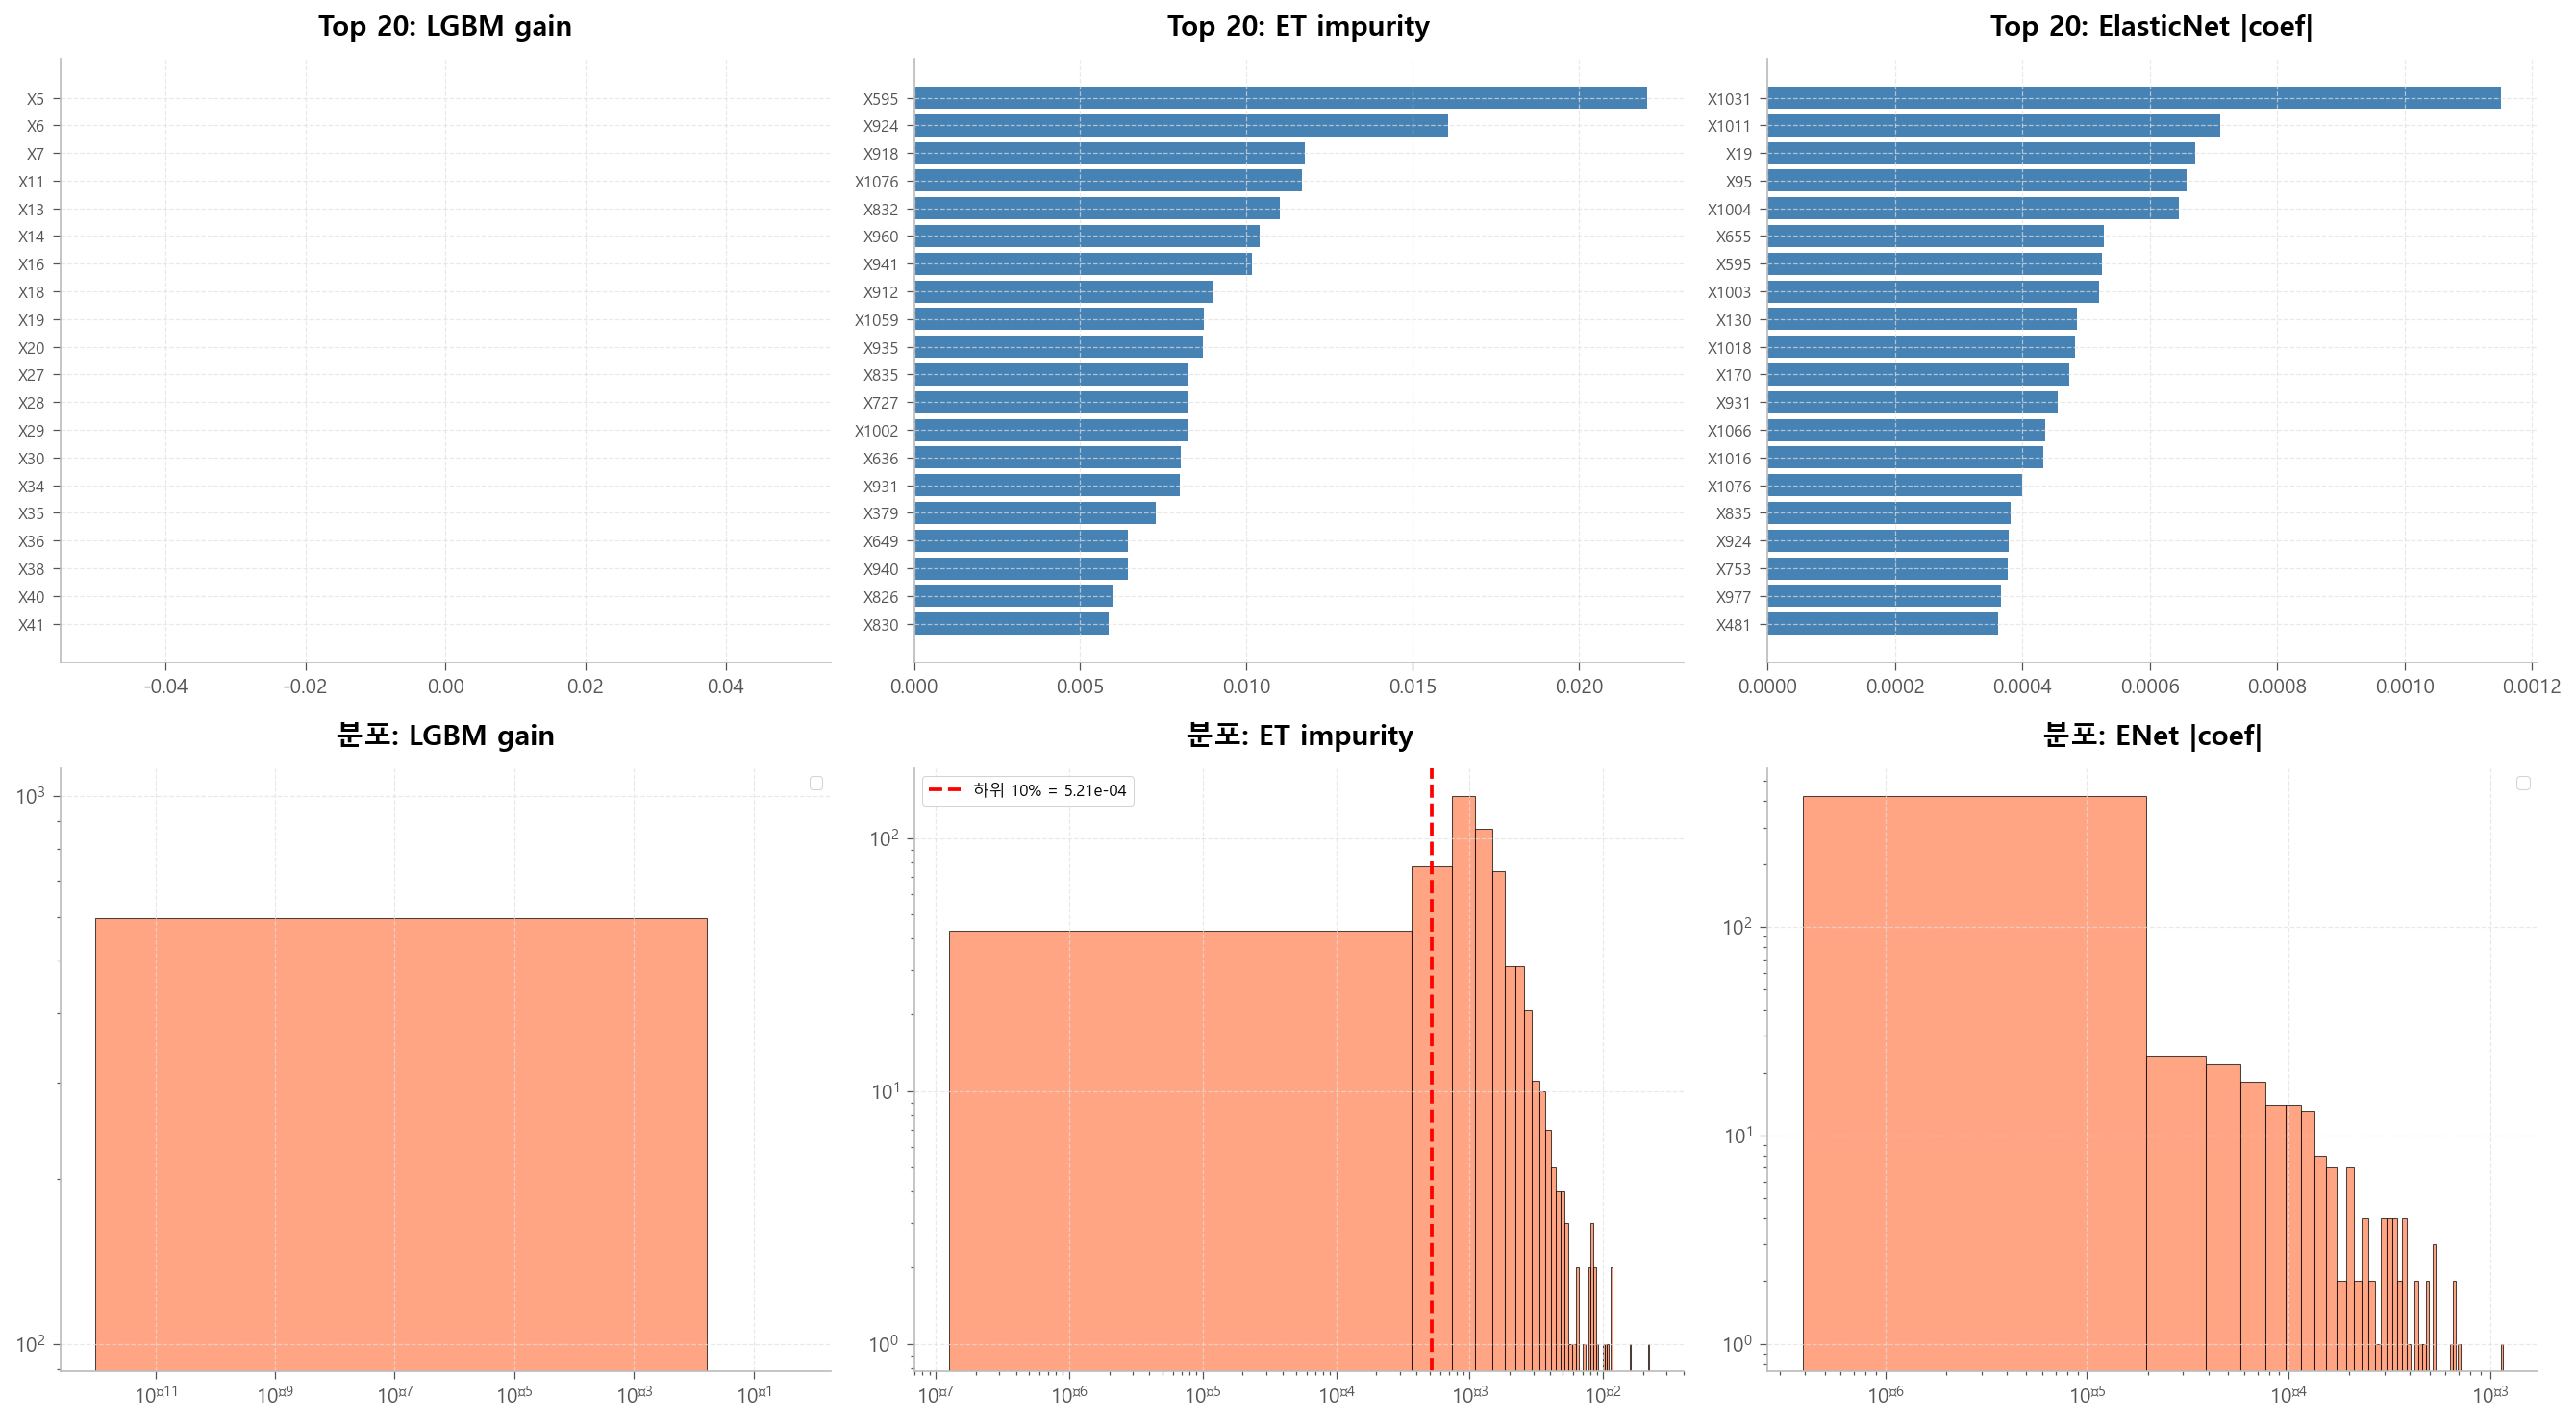

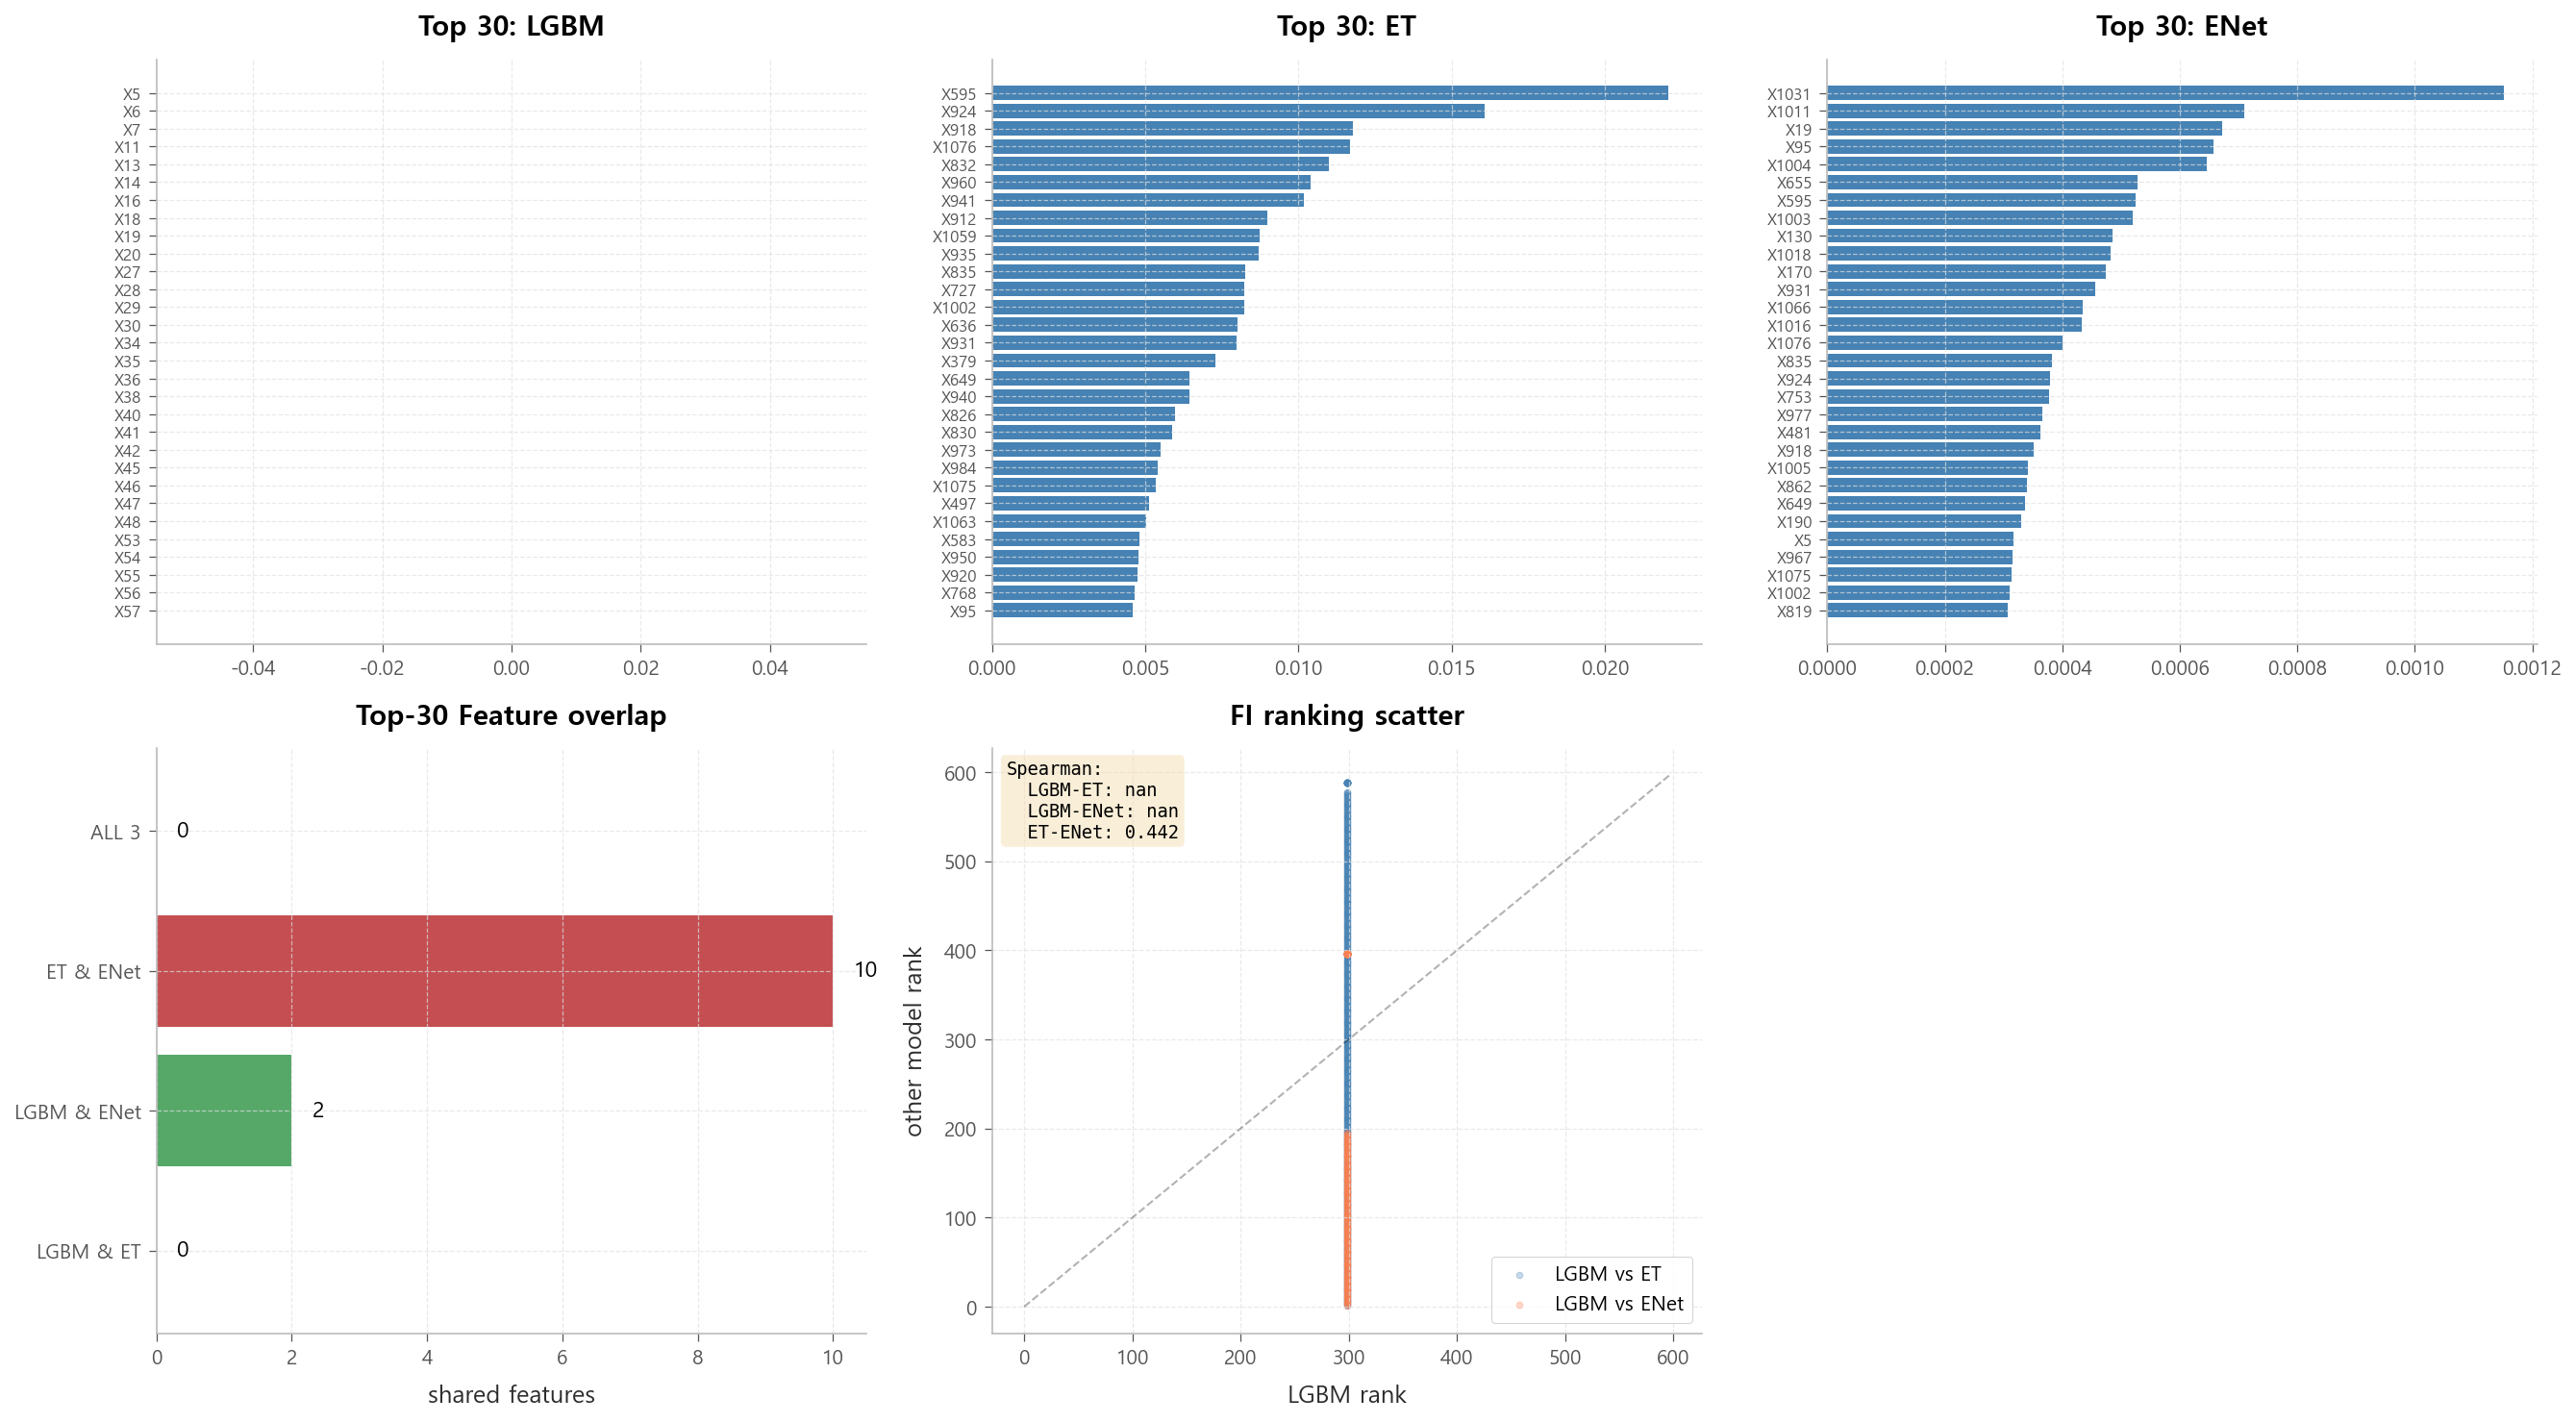

Top-30 intersection (3 models): 0

저장: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\feature_importance.csv
      c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\feature_remove_candidates.csv


In [8]:
# ============================================================
# Feature 제거 후보 진단 — 3-모델 importance/coef 교집합
# ============================================================
# LGBM gain / ET impurity / ENet |coef| 이 동시에 "무관"으로 본 feature를
# 3차 candidate로 내보낸다. 본 셀은 진단만, 실제 제거는 3차에서.

def _model_imp(models, kind):
    """fold별 모델 list → feature별 평균 importance/|coef| (1D).

    kind='tree'  : feature_importances_
    kind='linear': |coef_| (LogReg는 (1, n) 2D라 .ravel()로 1D 강제)
    """
    if kind == 'tree':
        return np.mean([m.feature_importances_ for m in models], axis=0)
    elif kind == 'linear':
        return np.mean([np.abs(m.coef_).ravel() for m in models], axis=0)
    raise ValueError(kind)


# ── 모델별 importance 추출 ──
lgbm_imp  = _model_imp(final['per_model_fold_models']['lgbm'], 'tree')
et_imp    = _model_imp(final['per_model_fold_models']['et'],   'tree')
enet_coef = _model_imp(final['per_model_fold_models']['enet'], 'linear')

# ── feature 이름 정합성: A4가 켜지면 'clf_proba_mean'이 마지막에 붙음 ──
n_imp = len(lgbm_imp)
n_sel = len(final['selected_cols'])
if n_imp == n_sel + 1:
    feat_names = list(final['selected_cols']) + ['clf_proba_mean']
elif n_imp == n_sel:
    feat_names = list(final['selected_cols'])
else:
    raise ValueError(
        f'feature length mismatch: importance={n_imp}, selected_cols={n_sel}')

df_imp = pd.DataFrame({
    'feature':        feat_names,
    'lgbm_gain':      lgbm_imp,
    'et_impurity':    et_imp,
    'enet_abs_coef':  enet_coef,
})

# ── 무관 판정 기준 (feature별 하위 10% + coef≈0) ──
thr_lgbm = df_imp['lgbm_gain'].quantile(0.10)
thr_et   = df_imp['et_impurity'].quantile(0.10)
df_imp['lgbm_weak'] = df_imp['lgbm_gain']   < thr_lgbm
df_imp['et_weak']   = df_imp['et_impurity'] < thr_et
df_imp['enet_zero'] = df_imp['enet_abs_coef'] < 1e-8

# ── 교집합 (3-모델 전부 무관) ──
intersection = df_imp[
    df_imp['lgbm_weak'] & df_imp['et_weak'] & df_imp['enet_zero']
]['feature'].tolist()
print(f'3-모델 모두 무관 판정: {len(intersection)}개 feature')
if intersection:
    print(f'  {intersection[:20]}' + (' ...' if len(intersection) > 20 else ''))

# ── 모델별 제거 후보 수 ──
print(f'\nLGBM 하위 10% (gain < {thr_lgbm:.4f}): {df_imp["lgbm_weak"].sum()}')
print(f'ET   하위 10% (impurity < {thr_et:.4f}): {df_imp["et_weak"].sum()}')
print(f'ENet coef ≈ 0                          : {df_imp["enet_zero"].sum()}')


# ── 시각화 (2 × 3 subplot) ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1행: Top-20 bar (3 모델)
for ax, (col, title) in zip(
    axes[0],
    [('lgbm_gain', 'LGBM gain'),
     ('et_impurity', 'ET impurity'),
     ('enet_abs_coef', 'ElasticNet |coef|')],
):
    top = df_imp.nlargest(20, col)
    ax.barh(range(20), top[col].values, color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top['feature'].values, fontsize=8)
    ax.set_title(f'Top 20: {title}')
    ax.invert_yaxis()

# 2행: 분포 histogram (log scale) + 하위 10% 선
for ax, (col, title) in zip(
    axes[1],
    [('lgbm_gain', 'LGBM gain'),
     ('et_impurity', 'ET impurity'),
     ('enet_abs_coef', 'ENet |coef|')],
):
    vals = df_imp[col].values
    # log scale용 — 0은 작은 값으로 대체
    vals_log = np.where(vals > 0, vals, vals[vals > 0].min() * 0.5 if (vals > 0).any() else 1e-12)
    ax.hist(vals_log, bins=60, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'분포: {title}')
    q10 = df_imp[col].quantile(0.10)
    if q10 > 0:
        ax.axvline(q10, color='red', linestyle='--', label=f'하위 10% = {q10:.2e}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



# -- Top-30 겹침 + 랭킹 산점도 (viz.py) --
from modules.viz import plot_fi_comparison
plot_fi_comparison(df_imp, [
    ('lgbm_gain', 'LGBM'),
    ('et_impurity', 'ET'),
    ('enet_abs_coef', 'ENet'),
], top_k=30)

# ── 저장 ──
if SAVE_OUTPUTS:
    imp_path = os.path.join(OOF_DIR, 'feature_importance.csv')
    df_imp.to_csv(imp_path, index=False)
    cand_path = os.path.join(OOF_DIR, 'feature_remove_candidates.csv')
    pd.Series(intersection, name='feature').to_csv(cand_path, index=False)
    print(f'\n저장: {imp_path}')
    print(f'      {cand_path}')

## 8. 포지션 가중치 sub-study (per-model Optuna)

OOF 로드 → 모델별 `w_pos` (w1~w4) Dirichlet 정규화, range `[0.15, 0.35]`, step `0.01`, 150 trials × 3 모델.

In [9]:
# ============================================================
# 포지션 가중치 — scipy SLSQP 수학해 (Speed C: Optuna 제거)
# ============================================================
from scipy.optimize import minimize

position_weight_results = {}
position_weight_rows = []
POS_ORDER = [1, 2, 3, 4]


def _reg_oof_df(model, split):
    """final dict에서 die-level DataFrame 재구성 (in-memory). Cell 8/9/10 공용.
    reg_level='position'일 때 final['unit_data']는 집계 후(unit-level)이므로
    die-level인 final['unit_data_die']를 우선 사용.
    """
    d = _get_die_or_unit(split)
    pred_key = "oof_pred" if split == "train" else f"{split}_pred"
    pred = final["per_model_reg"][model][pred_key]
    result = {
        KEY_COL:        d[KEY_COL].values,
        "split":        split,
        TARGET_COL:     d[TARGET_COL].values,
        "reg_pred_die": pred,
    }
    if POSITION_COL in d.columns:
        result["position"] = d[POSITION_COL].values
    return pd.DataFrame(result)


def find_best_pos_weights(pred_mat, y_val, bounds=(0.15, 0.35)):
    """SLSQP로 position 가중치 최적해 계산."""
    def obj(w):
        w_norm = w / w.sum()
        return np.sqrt(np.mean((y_val - pred_mat @ w_norm) ** 2))
    res = minimize(
        obj, x0=[0.25] * 4, method="SLSQP",
        bounds=[bounds] * 4,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0},
    )
    return res.x / res.x.sum(), res.fun


assert pipeline_config.get("reg_level") == "position", "Cell 8: reg_level=position 필수"

for m in e2e_params["reg_models"]:
    val = _reg_oof_df(m, "val")
    pivot = (val
             .pivot_table(index=KEY_COL, columns="position", values="reg_pred_die", aggfunc="mean")
             .reindex(columns=POS_ORDER))
    y_val = (val.groupby(KEY_COL, sort=False)[TARGET_COL].first()
                 .reindex(pivot.index).values)

    cfg = position_weight_substudy
    w_best, best_rmse = find_best_pos_weights(
        pivot.values, y_val,
        bounds=(cfg["weight_range"][0], cfg["weight_range"][1]),
    )
    position_weight_results[m] = {
        "best_w_pos":  w_best,
        "best_rmse":   best_rmse,
        "study":       None,
        "pred_pivot":  pivot,
        "y_val":       y_val,
    }
    print(f"{m:5s} | w_pos=[{w_best[0]:.3f},{w_best[1]:.3f},{w_best[2]:.3f},{w_best[3]:.3f}] | RMSE={best_rmse:.6f}")

for m, r in position_weight_results.items():
    w = r["best_w_pos"]
    position_weight_rows.append({
        "model": m, "val_rmse": r["best_rmse"],
        "w_p1": w[0], "w_p2": w[1], "w_p3": w[2], "w_p4": w[3],
    })

if SAVE_OUTPUTS:
    out_path = os.path.join(OOF_DIR, position_weight_substudy["save_path"])
    pd.DataFrame(position_weight_rows).to_csv(out_path, index=False)
    print("saved:", out_path)

lgbm  | w_pos=[0.250,0.250,0.250,0.250] | RMSE=0.005785
et    | w_pos=[0.250,0.250,0.250,0.250] | RMSE=0.005867
enet  | w_pos=[0.250,0.250,0.250,0.250] | RMSE=0.005917
saved: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\position_weights_substudy.csv


## 9. 모델 가중치 그리드서치

`w_pos` 적용된 unit-level `R_m` × 3 → simplex `step=0.025`, ~861 조합. Two-Stage 곱 (`P × R_combined`).

In [10]:
# ============================================================
# 모델 가중치 simplex 그리드서치 — step=0.025 → ~861 조합
# ============================================================
# 목적: 3개 회귀 모델(R_m) 가중 결합 + clf_proba 곱 → final 예측.
# 입력: Cell 8에서 만든 unit-level R_m (w_pos 이미 적용됨) + final['unit_data']['val']['clf_proba_mean'] (in-memory)
# 탐색: (w_lgbm, w_et, w_enet) simplex grid (합=1, 각≥0)
# objective: val unit-level RMSE

from itertools import product

def simplex_grid(n_dim, step):
    """합이 1이고 각 원소 >=0 인 n_dim 격자 포인트."""
    vals = np.round(np.arange(0.0, 1.0 + 1e-9, step), 6)
    pts = []
    for combo in product(vals, repeat=n_dim - 1):
        last = 1.0 - sum(combo)
        if -1e-9 <= last <= 1.0 + 1e-9:
            pts.append(tuple(combo) + (max(0.0, round(last, 6)),))
    return pts


grid = simplex_grid(len(e2e_params['reg_models']), model_weight_params['step'])
print(f'Simplex grid: {len(grid)} combinations (step={model_weight_params["step"]})')


# ── unit-level R_m (val) : 각 모델의 best w_pos 적용한 가중합 ──
unit_R_val = {}
for m in e2e_params['reg_models']:
    pivot  = position_weight_results[m]['pred_pivot']   # (n_units, 4)
    w_pos  = position_weight_results[m]['best_w_pos']
    unit_R_val[m] = pivot.values @ w_pos                # (n_units,)

# 단일 unit 기준 키/라벨 (첫 모델의 pivot index == 공통 ufs_serial 순서)
_ref_model = e2e_params['reg_models'][0]
ufs_order  = position_weight_results[_ref_model]['pred_pivot'].index.values
y_val_unit = position_weight_results[_ref_model]['y_val']   # 동일 순서

# ── clf_proba_unit (val) : final['unit_data']['val']['clf_proba_mean']에서 die → unit mean ──
# (in-memory: _prepare_unit_data에서 clf_result를 die-level로 붙인 컬럼, e2e_hpo.py:837)
# die-level에서 clf_proba_mean 접근 (unit_data는 집계 후라 해당 컬럼 없음)
d_val = _get_die_or_unit('val')
clf_proba_unit_val = (d_val.groupby(KEY_COL, sort=False)['clf_proba_mean']
                            .mean()
                            .reindex(ufs_order)
                            .values)

# ── [P0-2] zero_clip threshold 일관성 — rerun과 동일 규칙 ──
_zc_threshold = best_params.get(
    'zero_clip_threshold',
    e2e_params.get('zero_clip_threshold_fixed', 0.0),
)
print(f'[zero_clip] threshold = {_zc_threshold}  '
      f'(source: {"best_params" if "zero_clip_threshold" in best_params else "fixed"})')


# ── 그리드 탐색 ──
records = []
best_rmse = float('inf')
best_w = None
for weights in grid:
    r_combined = np.zeros_like(y_val_unit, dtype=float)
    for m, w in zip(e2e_params['reg_models'], weights):
        r_combined += w * unit_R_val[m]
    final_pred = clf_proba_unit_val * r_combined
    if pipeline_config.get('zero_clip', False):
        if _zc_threshold > 0:
            final_pred = np.where(final_pred < _zc_threshold, 0.0, final_pred)
        final_pred = np.clip(final_pred, 0.0, None)

    r = rmse(y_val_unit, final_pred)
    records.append({
        **{f'w_{m}': weights[i] for i, m in enumerate(e2e_params['reg_models'])},
        'val_rmse': r,
    })
    if r < best_rmse:
        best_rmse = r
        best_w    = weights

best_w_model = dict(zip(e2e_params['reg_models'], best_w))
print(f'\nbest model weights: {best_w_model}')
print(f'best val RMSE     : {best_rmse:.6f}')

grid_df = pd.DataFrame(records).sort_values('val_rmse').reset_index(drop=True)

# 저장 (top_k)
if SAVE_OUTPUTS:
    out_path = os.path.join(OOF_DIR, model_weight_params['save_path'])
    grid_df.head(model_weight_params['save_top_k']).to_csv(out_path, index=False)
    print(f'\n저장: {out_path}')

Simplex grid: 861 combinations (step=0.025)
[zero_clip] threshold = 0.002  (source: fixed)

best model weights: {'lgbm': np.float64(1.0), 'et': np.float64(0.0), 'enet': 0.0}
best val RMSE     : 0.006012

저장: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\model_weights_grid.csv


## 10. 최종 Ensemble + 로깅

`final_pred_val.csv` / `final_pred_test.csv` (스키마 C, 11컬럼) + `combined_best.json` + HybridScaler pickle + `log_experiment`.

In [11]:
# ============================================================
# 최종 Ensemble + 로깅 (스키마 C — 11컬럼, 3차 재사용용)
# ============================================================
# - val/test 모두 처리 (EVAL_VAL/EVAL_TEST 스위치에 따라 분기)
# - final = clf_proba_unit × Σ_m w_m · (Σ_p w_pos[m,p] · die_pred[m,p])
# - final_pred_{val,test}.csv, combined_best.json, hybrid_scaler.pkl
# - ★ CSV I/O 제거 — final dict에서 in-memory로 조회 (_reg_oof_df 재사용)
import joblib
import json as _json
from datetime import datetime

POS_ORDER = [1, 2, 3, 4]

# ── [P0-2] zero_clip threshold 일관성: best_params 우선 (rerun과 동일 규칙) ──
_zc_threshold = best_params.get(
    'zero_clip_threshold',
    e2e_params.get('zero_clip_threshold_fixed', 0.0),
)
print(f'[zero_clip] threshold = {_zc_threshold}  '
      f'(source: {"best_params" if "zero_clip_threshold" in best_params else "fixed"})')


# ── in-memory 헬퍼 (4개 — 기존 CSV 읽기 대체) ──

def _unit_R_from_oof(split_name):
    """split별 모델별 unit-level R 벡터 반환 (best w_pos 적용).
    _reg_oof_df(Cell 8 정의)로 in-memory die-level df 생성 → pivot.
    """
    ref_m = e2e_params['reg_models'][0]
    oof0 = _reg_oof_df(ref_m, split_name)
    pivot0 = (oof0.pivot_table(index=KEY_COL, columns='position',
                                values='reg_pred_die', aggfunc='mean')
                   .reindex(columns=POS_ORDER))
    ufs_order = pivot0.index.values
    unit_R = {}
    for m in e2e_params['reg_models']:
        oof_m = _reg_oof_df(m, split_name)
        pivot = (oof_m.pivot_table(index=KEY_COL, columns='position',
                                    values='reg_pred_die', aggfunc='mean')
                      .reindex(pivot0.index)
                      .reindex(columns=POS_ORDER))
        w_pos = position_weight_results[m]['best_w_pos']
        unit_R[m] = pivot.values @ w_pos
    return ufs_order, unit_R


def _unit_clf_proba_from_oof(split_name, ufs_order):
    """final['unit_data'][split]['clf_proba_mean']에서 die → unit mean."""
    d = _get_die_or_unit(split_name)
    return (d.groupby(KEY_COL, sort=False)['clf_proba_mean']
              .mean()
              .reindex(ufs_order)
              .values)


def _unit_clf_proba_per_model(split_name, ufs_order):
    """final['per_model_clf'][m][pos] → die-level proba concat → unit mean."""
    out = {}
    d = _get_die_or_unit(split_name)
    for m in e2e_params['clf_models']:
        proba_arr = np.concatenate([
            final['per_model_clf'][m][pos][f'{split_name}_proba']
            for pos in sorted(final['per_model_clf'][m].keys())
        ])
        out[m] = (pd.Series(proba_arr, index=d[KEY_COL].values)
                    .groupby(level=0, sort=False)
                    .mean()
                    .reindex(ufs_order)
                    .values)
    return out


def _unit_y_true(split_name, ufs_order):
    """final['unit_data'][split][TARGET_COL] → unit-level first."""
    d = _get_die_or_unit(split_name)
    return (d.groupby(KEY_COL, sort=False)[TARGET_COL]
              .first()
              .reindex(ufs_order)
              .values)


def _apply_final(clf_proba_unit, unit_R, w_model):
    """[P0-2] zero_clip threshold는 셀 상단 _zc_threshold로 rerun과 일관 사용."""
    r_combined = np.zeros_like(clf_proba_unit, dtype=float)
    for m, w in zip(e2e_params['reg_models'], w_model):
        r_combined += w * unit_R[m]
    final_pred = clf_proba_unit * r_combined
    if pipeline_config.get('zero_clip', False):
        if _zc_threshold > 0:
            final_pred = np.where(final_pred < _zc_threshold, 0.0, final_pred)
        final_pred = np.clip(final_pred, 0.0, None)
    return final_pred, r_combined


def _make_schema_c(ufs, y_true, y_pred, proba_unit, R_combined, unit_R, proba_per):
    df = pd.DataFrame({
        KEY_COL:           ufs,
        'y_true':          y_true,
        'y_pred':          y_pred,
        'clf_proba_unit':  proba_unit,
        'R_combined_unit': R_combined,
    })
    for m in e2e_params['reg_models']:
        df[f'R_{m}_unit'] = unit_R[m]
    for m in e2e_params['clf_models']:
        df[f'clf_proba_{m}'] = proba_per[m]
    return df


w_model_arr = np.array([best_w_model[m] for m in e2e_params['reg_models']])

# ── [P0-3] EVAL_VAL 분기: val RMSE 계산 + CSV 저장 ──
val_rmse_final = None
final_val_df   = None
if EVAL_VAL:
    ufs_val, unit_R_val_all = _unit_R_from_oof('val')
    proba_unit_val = _unit_clf_proba_from_oof('val', ufs_val)
    proba_per_val  = _unit_clf_proba_per_model('val', ufs_val)
    y_val_unit     = _unit_y_true('val', ufs_val)
    final_val, R_combined_val = _apply_final(proba_unit_val, unit_R_val_all, w_model_arr)
    val_rmse_final = float(rmse(y_val_unit, final_val))
    final_val_df = _make_schema_c(ufs_val, y_val_unit, final_val,
                                   proba_unit_val, R_combined_val,
                                   unit_R_val_all, proba_per_val)
    print(f'[val]  RMSE = {val_rmse_final:.6f}')
else:
    print('[val]  EVAL_VAL=False → 계산 생략')

# ── [P0-3] EVAL_TEST 분기 ──
test_rmse_final = None
final_test_df   = None
if EVAL_TEST:
    ufs_test, unit_R_test_all = _unit_R_from_oof('test')
    proba_unit_test = _unit_clf_proba_from_oof('test', ufs_test)
    proba_per_test  = _unit_clf_proba_per_model('test', ufs_test)
    y_test_unit     = _unit_y_true('test', ufs_test)
    final_test, R_combined_test = _apply_final(proba_unit_test, unit_R_test_all, w_model_arr)
    test_rmse_final = float(rmse(y_test_unit, final_test))
    final_test_df = _make_schema_c(ufs_test, y_test_unit, final_test,
                                    proba_unit_test, R_combined_test,
                                    unit_R_test_all, proba_per_test)
    print(f'[test] RMSE = {test_rmse_final:.6f}')
else:
    print('[test] EVAL_TEST=False → 계산 생략 (test peeking 방지)')


# ── CSV 저장 (SAVE_OUTPUTS & 각 스위치 AND) ──
if SAVE_OUTPUTS:
    print(f'\n저장:')
    if EVAL_VAL and final_val_df is not None:
        val_path = os.path.join(OOF_DIR, ensemble_save['save_final_val'])
        final_val_df.to_csv(val_path, index=False)
        print(f'  {val_path}')
    if EVAL_TEST and final_test_df is not None:
        test_path = os.path.join(OOF_DIR, ensemble_save['save_final_test'])
        final_test_df.to_csv(test_path, index=False)
        print(f'  {test_path}')


# ── [P2] combined_best.json 보강: standalone 재현성 ──
combined_best = {
    'exp_id':      EXP_ID,
    'saved_at':    datetime.now().isoformat(timespec='seconds'),
    'val_rmse':    val_rmse_final,
    'test_rmse':   test_rmse_final,
    'best_w_pos':  {m: position_weight_results[m]['best_w_pos'].tolist()
                    for m in e2e_params['reg_models']},
    'best_w_model': {m: float(best_w_model[m])
                     for m in e2e_params['reg_models']},
    'clf_models':  list(e2e_params['clf_models']),
    'reg_models':  list(e2e_params['reg_models']),
    'calibration': e2e_params['calibration'],
    'add_clf_proba_to_reg': e2e_params['add_clf_proba_to_reg'],
    'iso_args':    final.get('iso_args'),
    'lds_args':    final.get('lds_args'),
    'scaler_path': ensemble_save['save_scaler'],
    # ★ [P2] 재현성 보강
    'target_transform':  TARGET_TRANSFORM,
    'clip_y_extreme':    CLIP_Y_EXTREME,
    'exclude_cols':      list(EXCLUDE_COLS),
    'pipeline_config':   dict(pipeline_config),
    'selected_cols':     list(final['selected_cols']),
    'best_params':       {k: (float(v) if isinstance(v, np.floating)
                              else int(v) if isinstance(v, np.integer)
                              else v)
                          for k, v in best_params.items()},
    'zero_clip_threshold_used': _zc_threshold,
    'eval_flags': {'EVAL_VAL': EVAL_VAL, 'EVAL_TEST': EVAL_TEST},
    'n_trials':    e2e_params['n_trials'],
    'n_folds_main':   e2e_params['n_folds'],
    'n_folds_rerun':  rerun_params['n_folds'],
}

if SAVE_OUTPUTS:
    comb_path = os.path.join(OOF_DIR, ensemble_save['save_combined'])
    with open(comb_path, 'w', encoding='utf-8') as f:
        _json.dump(combined_best, f, indent=2, ensure_ascii=False, default=str)
    print(f'  {comb_path}')

    scaler_path = os.path.join(OOF_DIR, ensemble_save['save_scaler'])
    joblib.dump(final['scaler'], scaler_path)
    print(f'  {scaler_path}  ({type(final["scaler"]).__name__})')


# ── log_experiment (EVAL 스위치에 따라 None 허용) ──
log_experiment(
    csv_path=EXP_CSV_PATH,
    exp_id=EXP_ID,
    exp_type=EXP_TYPE,
    best_model=f'ensemble({"+".join(e2e_params["reg_models"])})',
    val_rmse=val_rmse_final,
    test_rmse=test_rmse_final,
    n_features=len(final['selected_cols']),
    memo=EXP_MEMO,
    user=USER,
    n_trials=e2e_params['n_trials'],
    csv_gdrive_id=CSV_GDRIVE_ID,
)
_val_str = f'{val_rmse_final:.6f}' if val_rmse_final is not None else 'N/A(EVAL_VAL=False)'
_test_str = f'{test_rmse_final:.6f}' if test_rmse_final is not None else 'N/A(EVAL_TEST=False)'
print(f'\n Cell 10 완료: val_rmse={_val_str}, test_rmse={_test_str}')

[zero_clip] threshold = 0.002  (source: fixed)
[val]  RMSE = 0.006012
[test] RMSE = 0.008652

저장:
  c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\final_pred_val.csv
  c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\final_pred_test.csv
  c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\combined_best.json
  c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\oof\1-999-001\hybrid_scaler.pkl  (HybridScaler)

실험 기록 완료: 1-999-001
  타입: ensemble + HPO | 베스트: ensemble(lgbm+et+enet) | user: jh
  Val RMSE:  0.006012
  Test RMSE: 0.008652
  피처수: 596 | n_trials: 1 | 메모: 2차 funnel: 분류·회귀 3-모델 앙상블(LGBM+ET+선형), hybrid_scale 외부 1회, LDS, IsoForest score, Isotonic cal, A4
  csv: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\2차 실험\experiments.csv

 Cell 10 완료: val_rmse=0.006012, test_rmse=0.008652


## 12. SHAP 분석

reg 3모델 × beeswarm + bar (mean|SHAP|). val 데이터 1000 샘플 서브셋.

In [12]:
# SHAP 분석 -- reg 3모델 (val 1000 샘플)
from modules.viz import plot_shap_analysis

# 학습 시 A4(add_clf_proba_to_reg)로 clf_proba_mean이 feature에 추가됐으면 포함
shap_cols = list(final['selected_cols'])
if e2e_params.get('add_clf_proba_to_reg') and 'clf_proba_mean' not in shap_cols:
    shap_cols.append('clf_proba_mean')

_d_val = _get_die_or_unit('val')
X_val_arr = _d_val[shap_cols].values
models_first_fold = [
    final['per_model_fold_models'].get(m, [None])[0]
    for m in e2e_params['reg_models']
]
plot_shap_analysis(
    models_first_fold, X_val_arr, shap_cols,
    model_names=list(e2e_params['reg_models']),
)


## 13. Optuna 결과 시각화

Main study (optimization history + param importance) + position sub-study 3모델.

In [13]:
# Optuna 시각화 -- main study + position sub-study
from modules.viz import plot_optuna_results, plot_optuna_substudy

plot_optuna_results(study, title_prefix='Main Study -- ')

# position sub-study (scipy 전환 시 study=None -> 자동 스킵)
sub_studies = {m: position_weight_results[m].get('study')
               for m in e2e_params['reg_models']}
plot_optuna_substudy(sub_studies)

## 14. Stage 1 clf 오차행렬 + Precision-Recall 곡선

val split 기준. threshold 0.5.

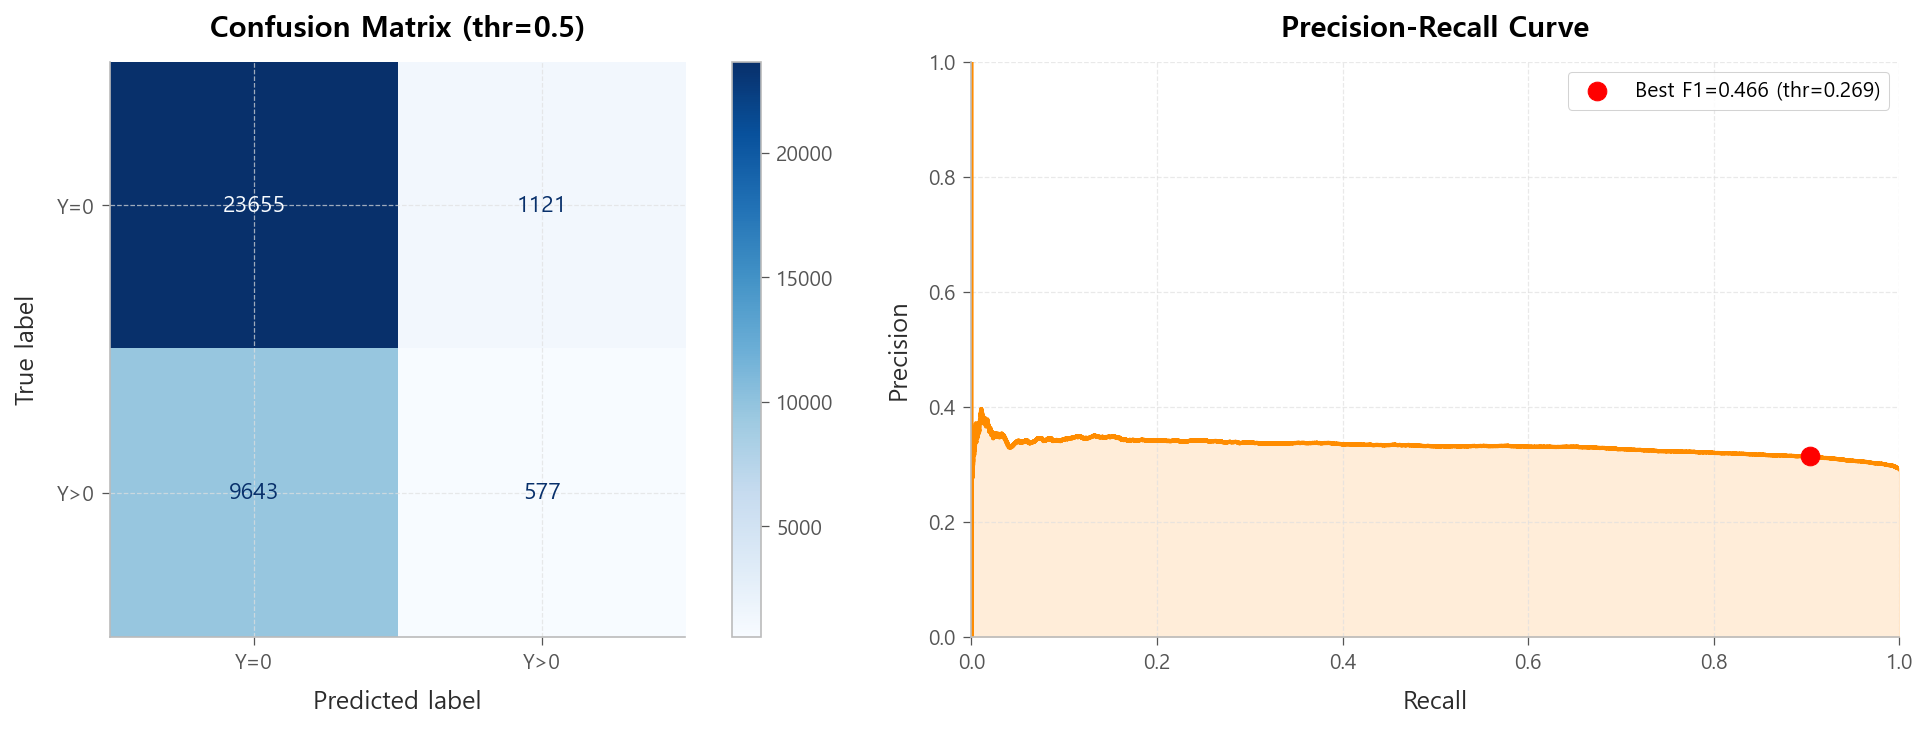

AUC=0.5683  AP=0.3305  F1=0.0968 (thr=0.5)


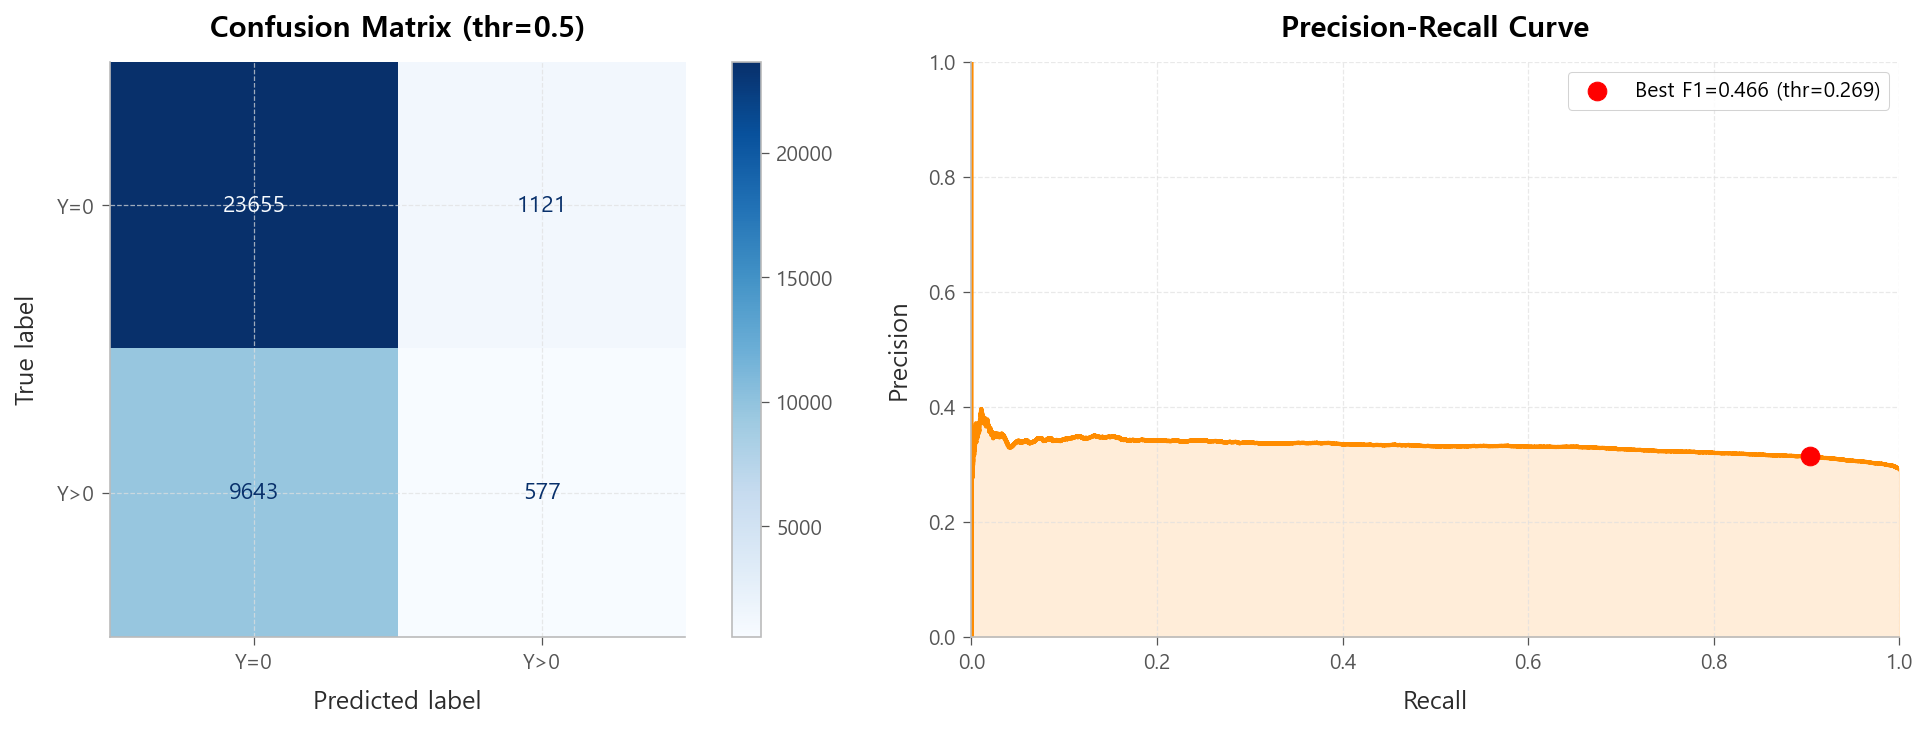

In [ ]:
# Stage 1 clf 오차행렬 + PR 곡선 (val)
from modules.viz import plot_clf_confusion_pr

d_val = _get_die_or_unit('val')
y_bin_val = (d_val[TARGET_COL] > 0).astype(int).values
proba_val = d_val['clf_proba_mean'].values
plot_clf_confusion_pr(y_bin_val, proba_val)

## 15. y_true vs y_pred 히스토그램 (영역차트)

train/val/test 3패널. 반투명 overlay로 예측 분포와 실측 분포 비교.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


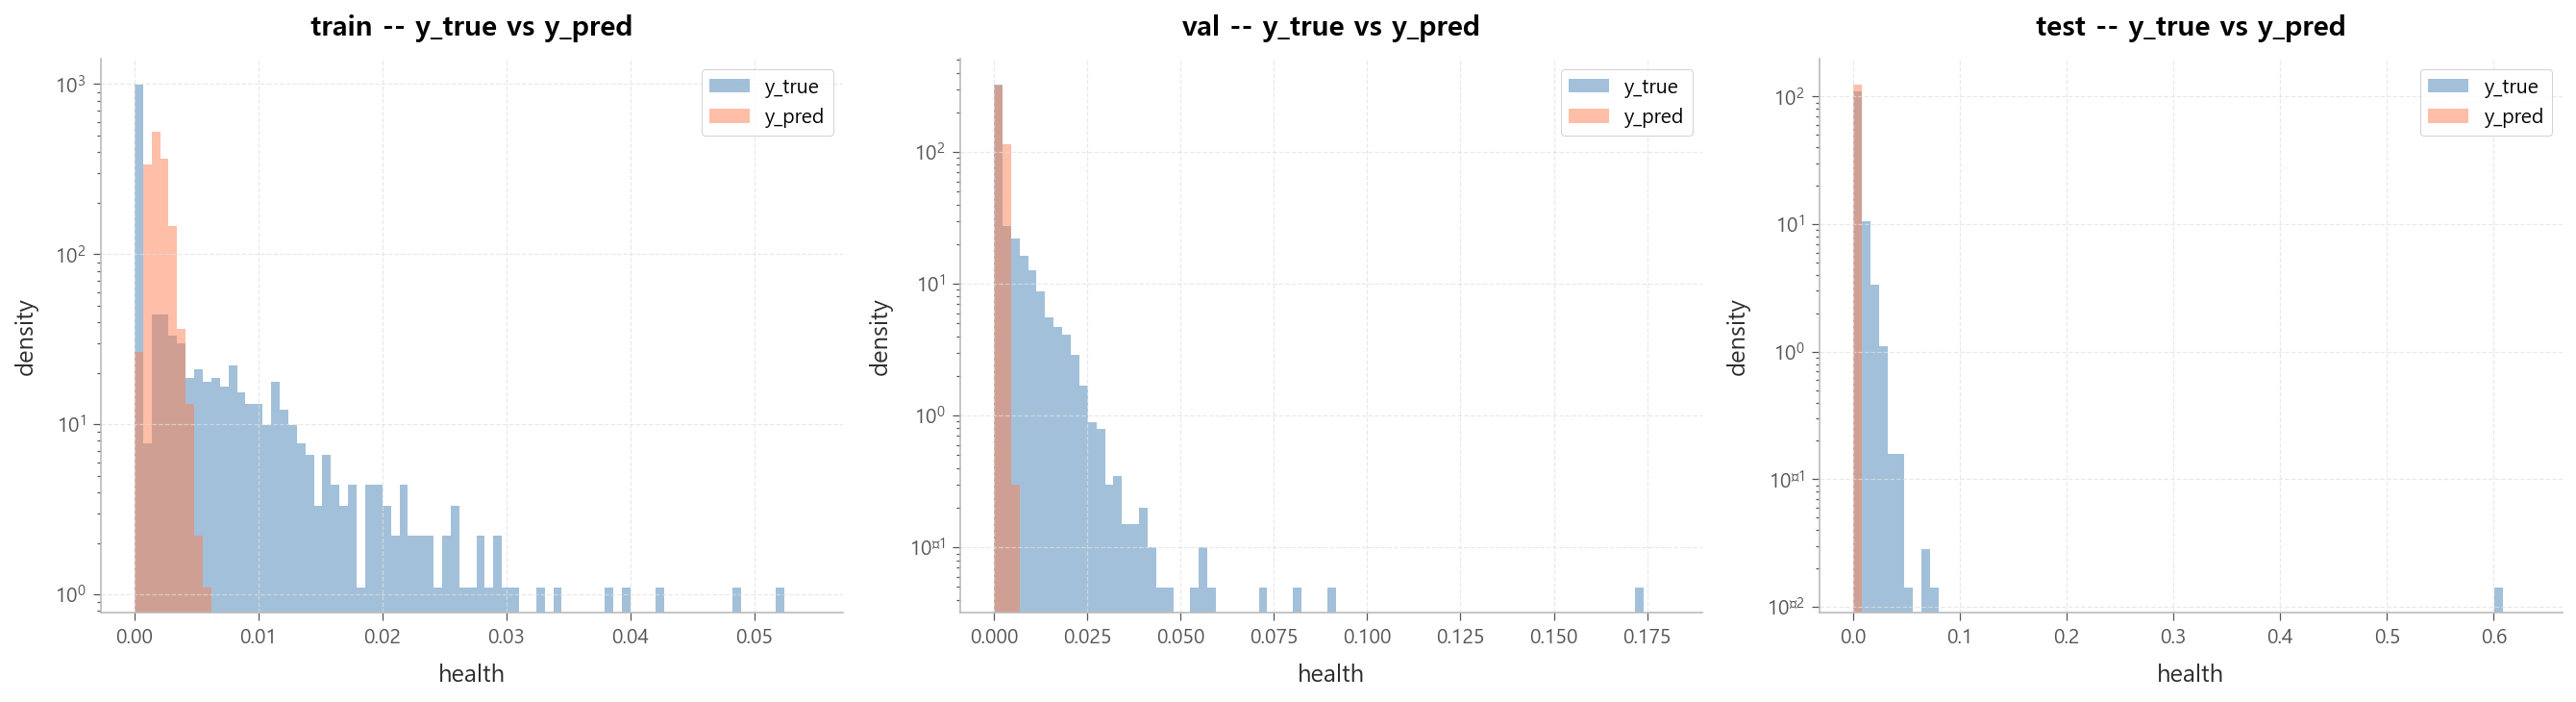

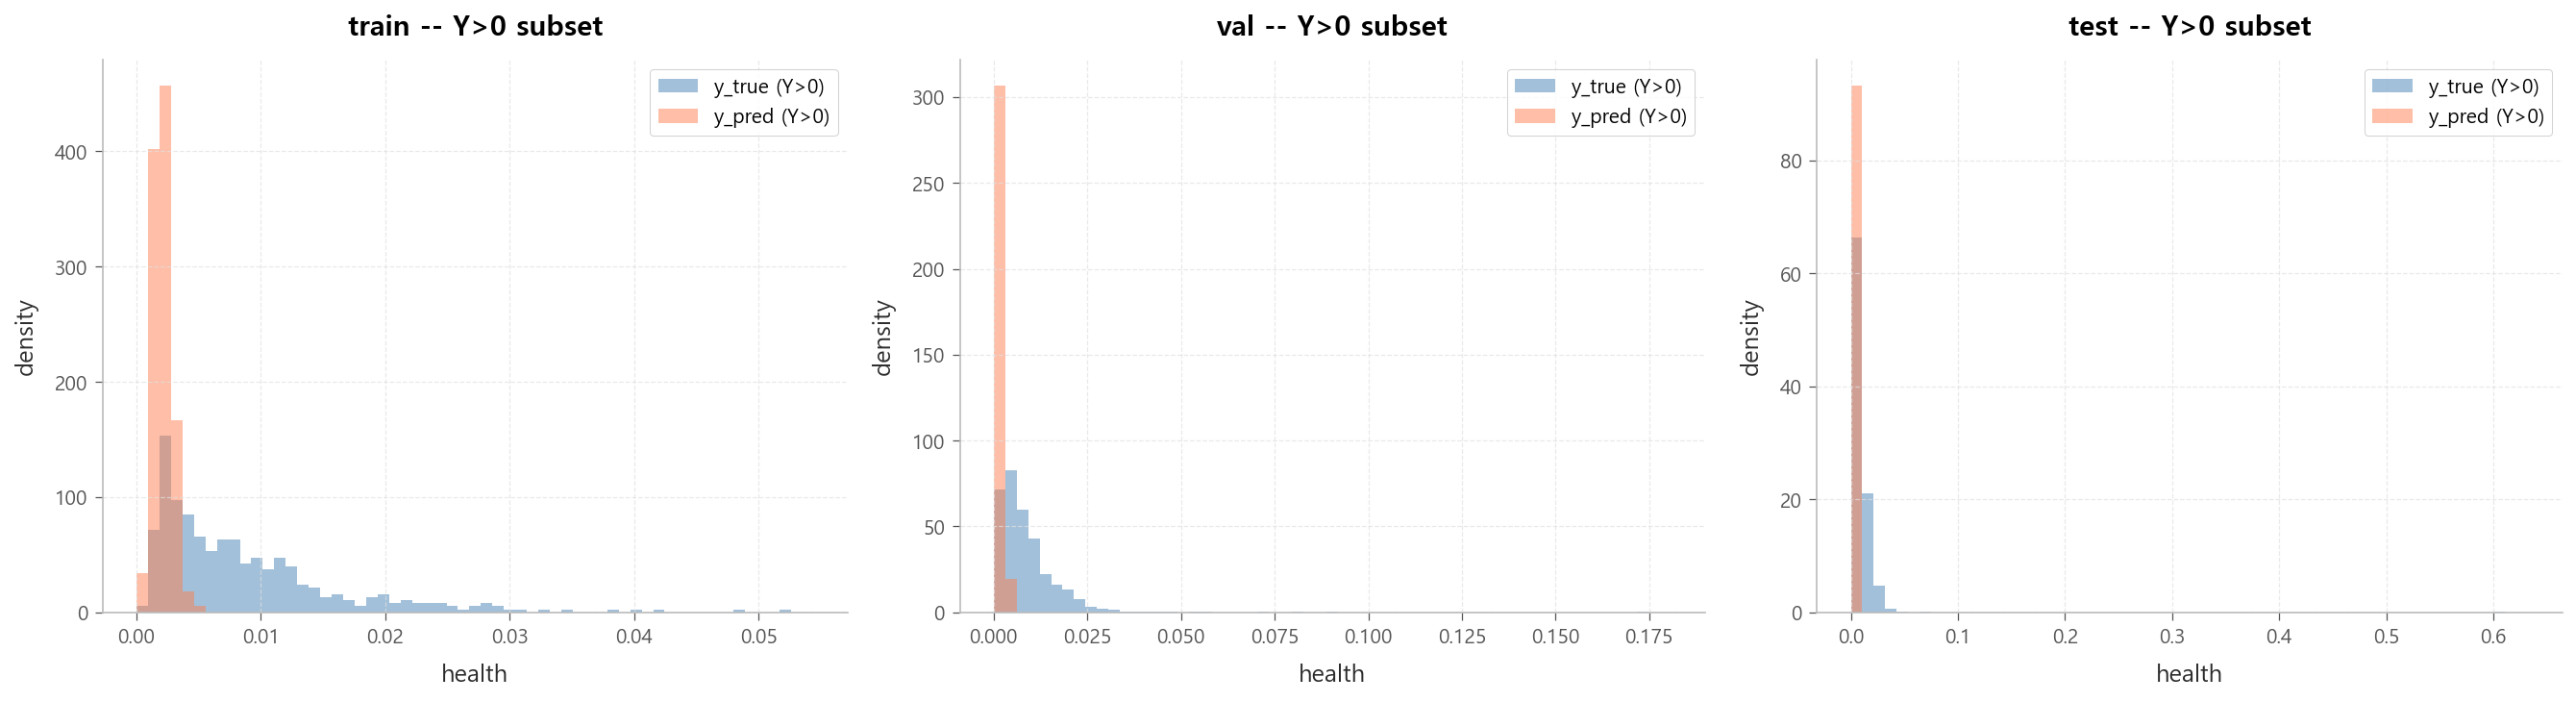

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


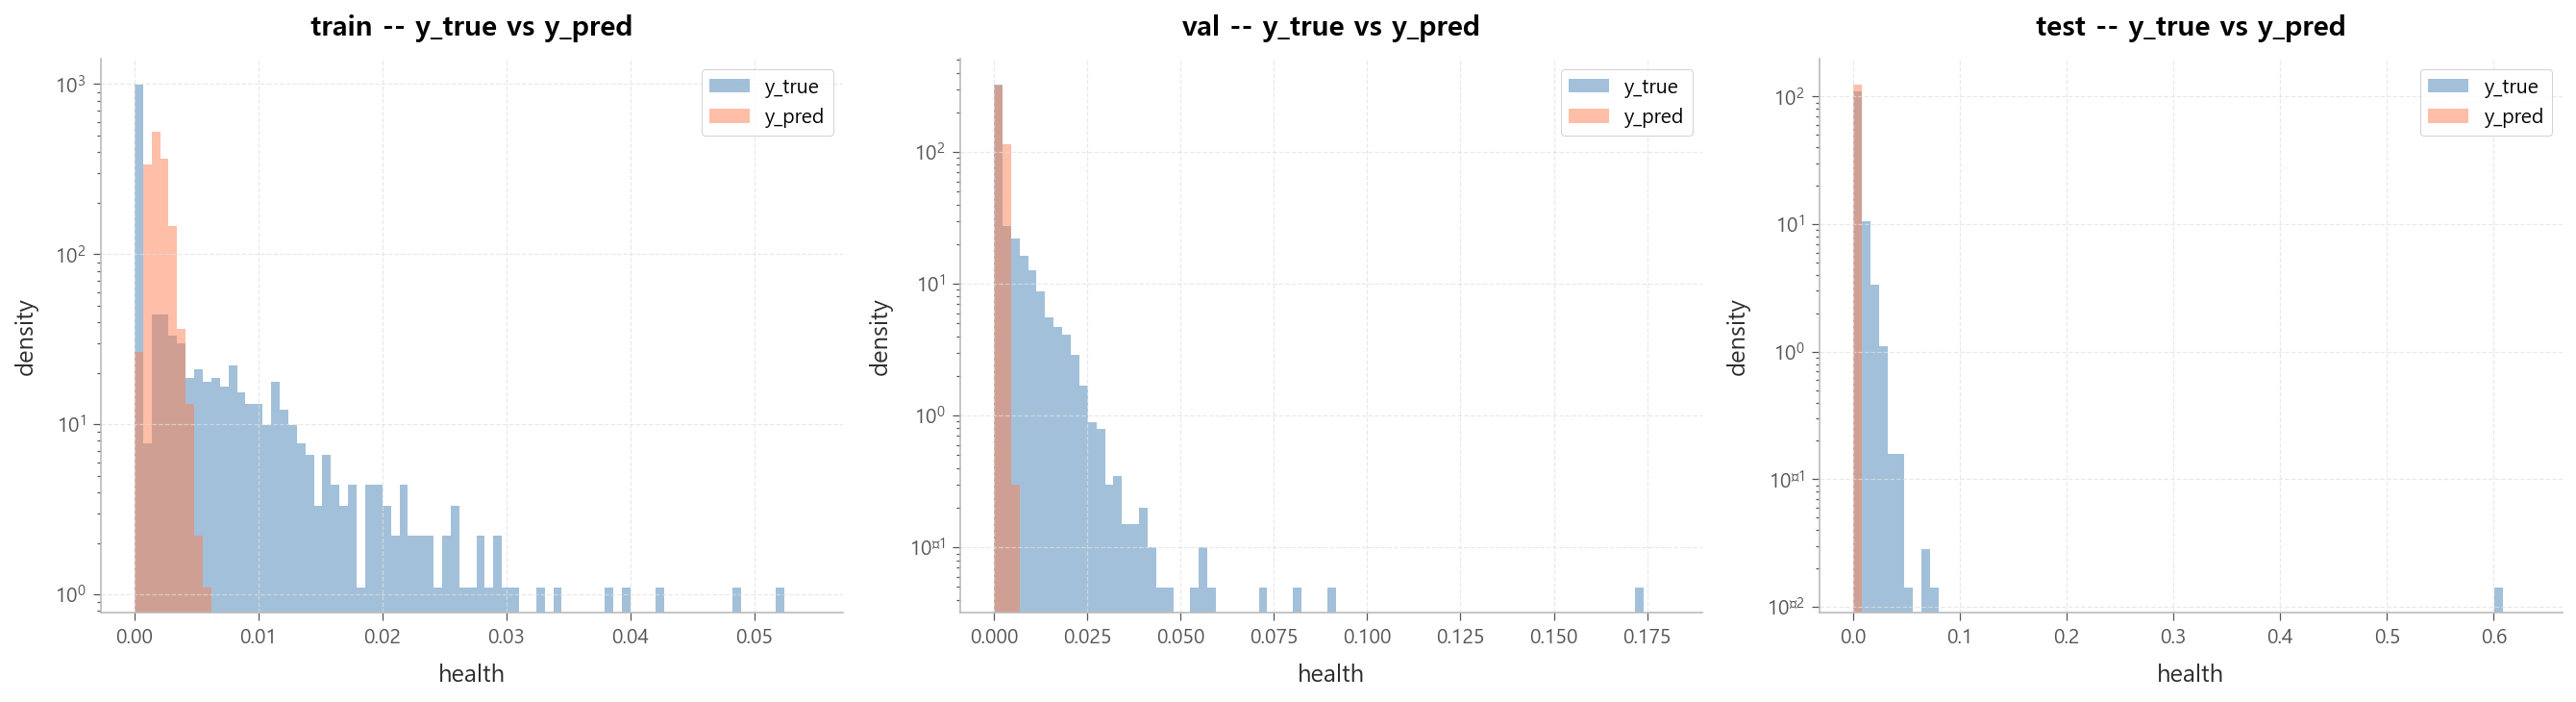

In [ ]:
# y_true vs y_pred 히스토그램 -- train/val/test
from modules.viz import plot_pred_histogram

splits_data = {}
for split_name in ['train', 'val', 'test']:
    d = _get_die_or_unit(split_name)
    y_true_unit = d.groupby(KEY_COL, sort=False)[TARGET_COL].first().values
    pred_key = 'oof_pred' if split_name == 'train' else f'{split_name}_pred'
    per_model_preds = [final['per_model_reg'][m][pred_key] for m in e2e_params['reg_models']]
    die_pred = np.mean(per_model_preds, axis=0)
    pred_df = pd.DataFrame({KEY_COL: d[KEY_COL].values, '_pred': die_pred})
    y_pred_unit = pred_df.groupby(KEY_COL, sort=False)['_pred'].mean().values
    splits_data[split_name] = (y_true_unit, y_pred_unit)

plot_pred_histogram(splits_data, target_col=TARGET_COL)

## 11. 시각화

포지션 가중치 bar × 3모델 + 모델 가중치 heatmap + 예측 vs 실측 + Pearson/Spearman + residual + RMSE 비교 + Top-10 importance.

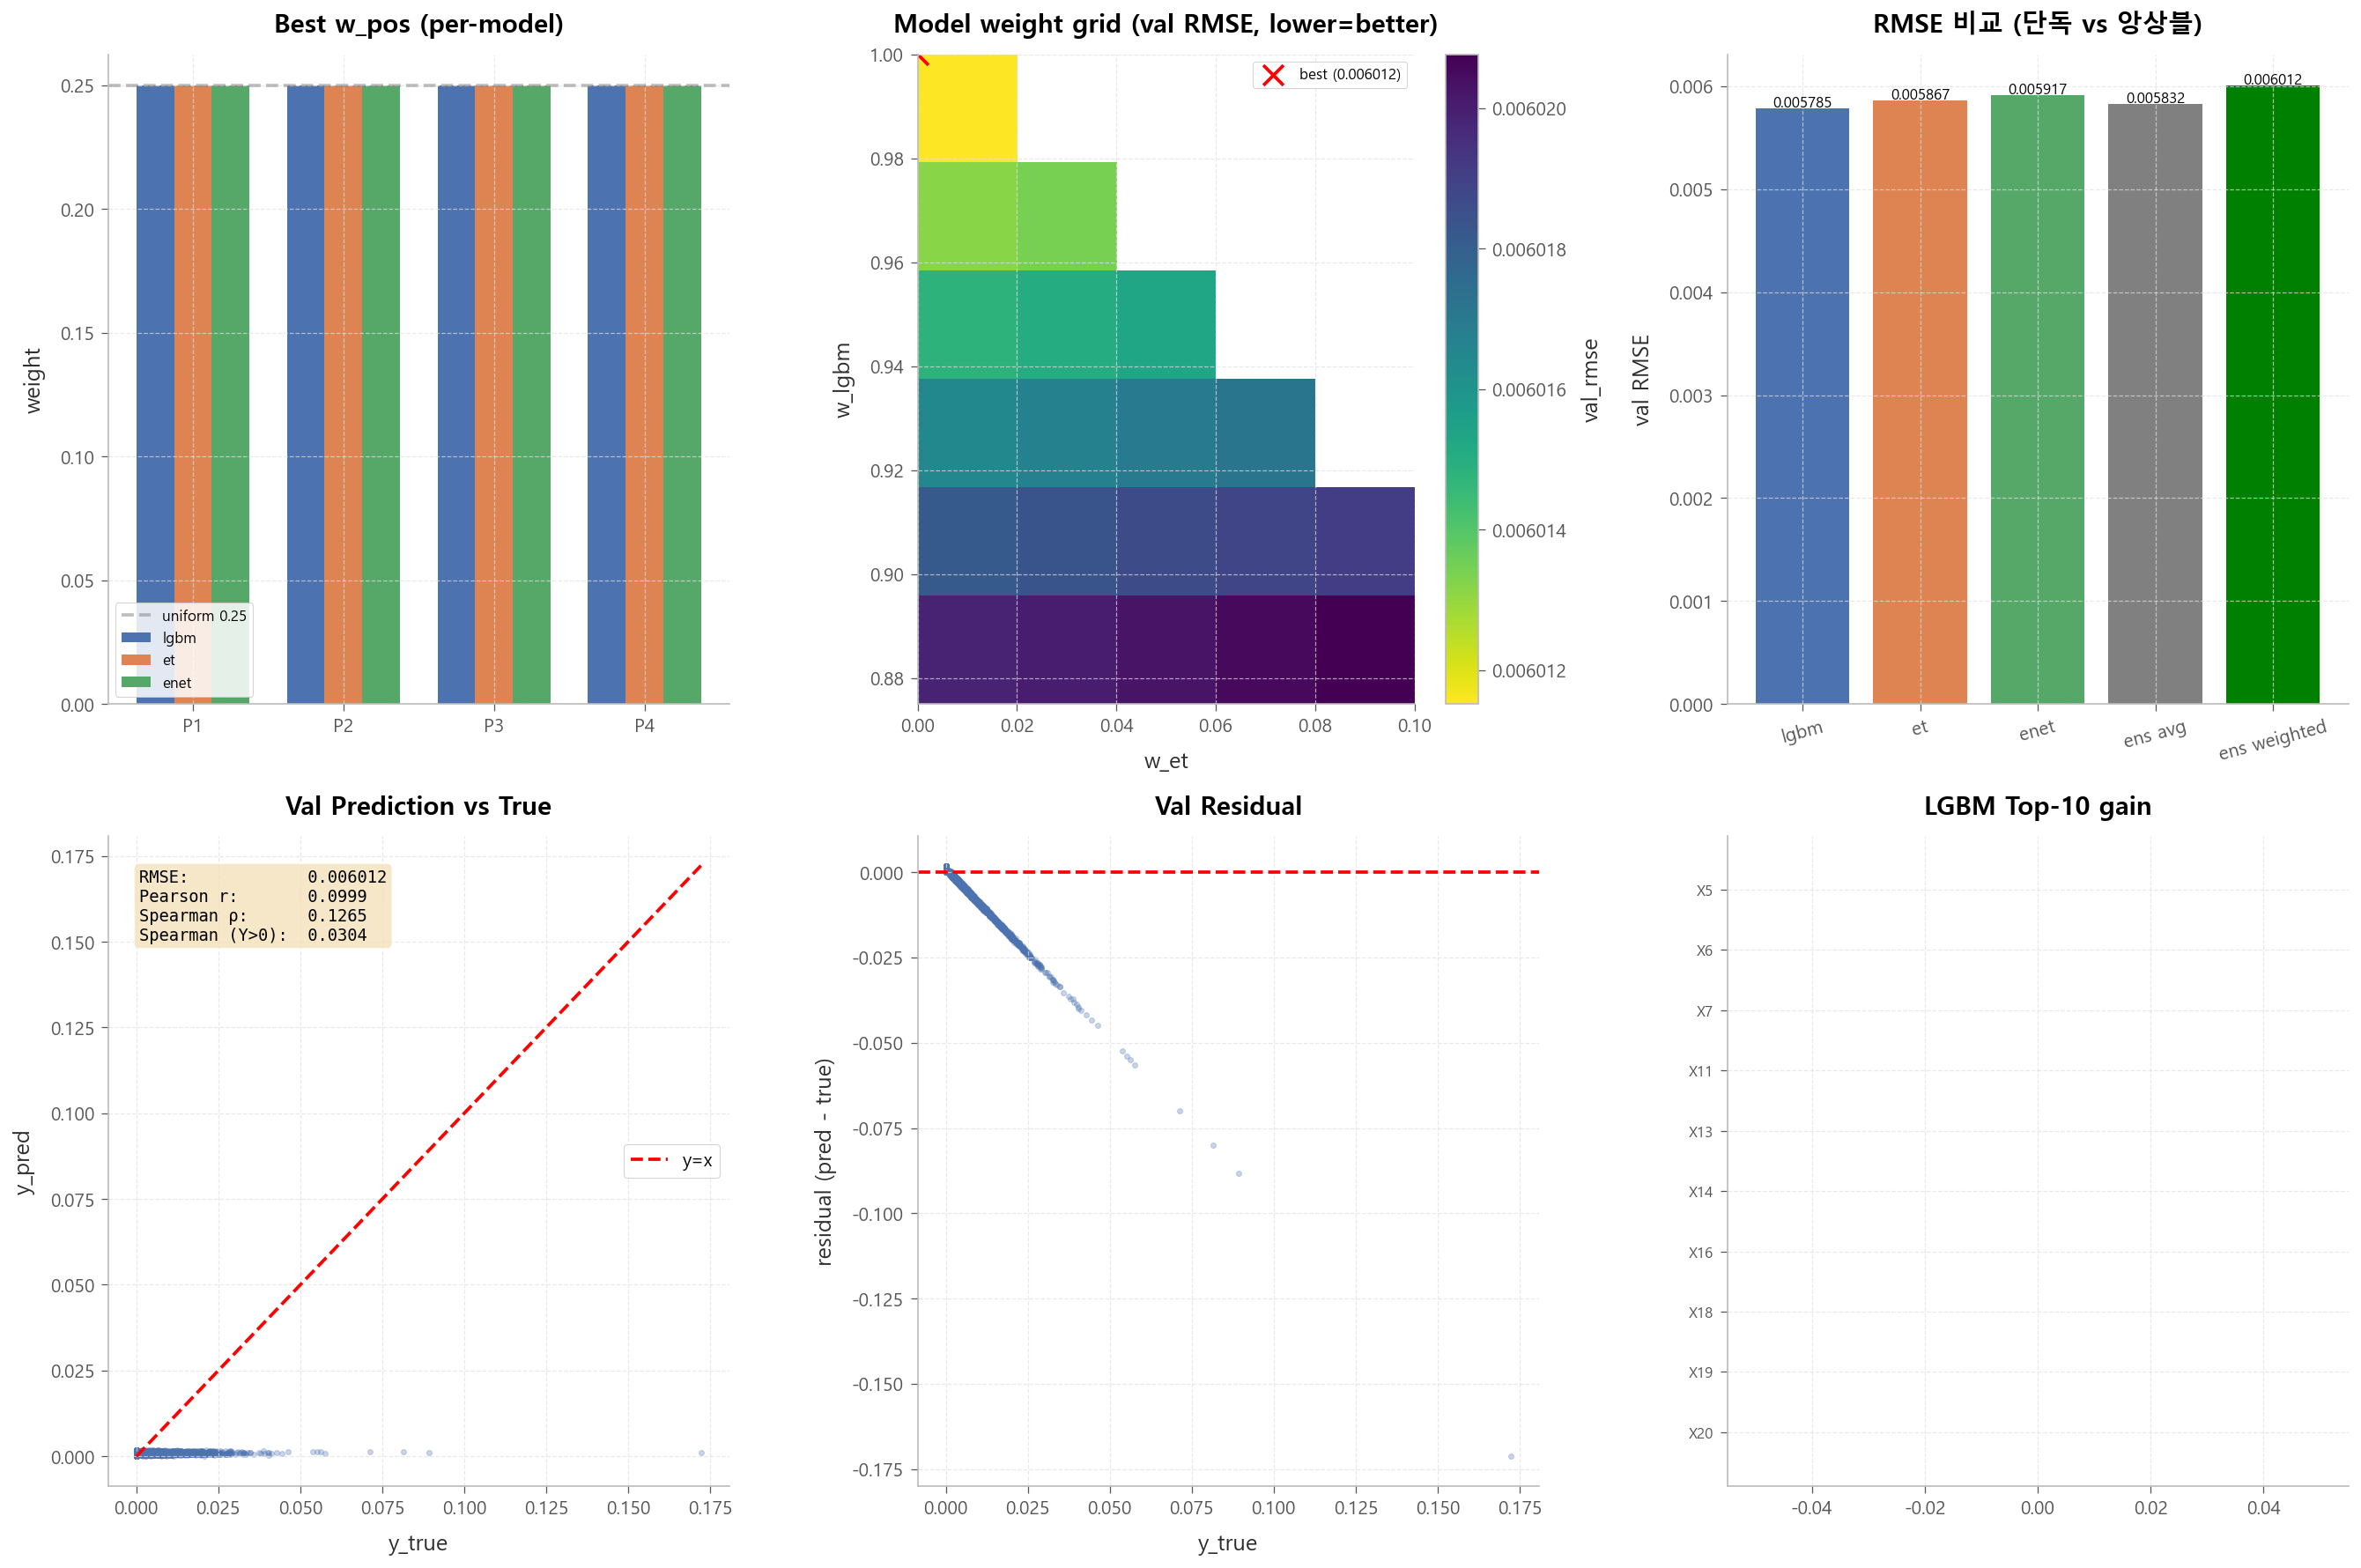


✅ 시각화 완료


In [16]:
# ============================================================
# 시각화 — 포지션 w / 모델 w / 예측 vs 실측 / residual / RMSE / importance
# ============================================================
from scipy.stats import pearsonr, spearmanr


fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ── (0,0) 포지션 가중치 bar (모델별 묶음) ──
ax = axes[0, 0]
x_pos = np.arange(4)
bar_w = 0.25
for i, m in enumerate(e2e_params['reg_models']):
    w = position_weight_results[m]['best_w_pos']
    ax.bar(x_pos + i * bar_w, w, bar_w, label=m)
ax.axhline(0.25, color='gray', linestyle='--', alpha=0.5, label='uniform 0.25')
ax.set_xticks(x_pos + bar_w)
ax.set_xticklabels(['P1', 'P2', 'P3', 'P4'])
ax.set_ylabel('weight')
ax.set_title('Best w_pos (per-model)')
ax.legend(fontsize=8)

# ── (0,1) 모델 가중치 heatmap ──
ax = axes[0, 1]
grid_csv = os.path.join(OOF_DIR, model_weight_params['save_path'])
if os.path.isfile(grid_csv):
    gdf = pd.read_csv(grid_csv)
    piv = gdf.pivot_table(index='w_lgbm', columns='w_et', values='val_rmse', aggfunc='min')
    im = ax.imshow(piv.values, cmap='viridis_r', origin='lower',
                   extent=[piv.columns.min(), piv.columns.max(),
                           piv.index.min(), piv.index.max()],
                   aspect='auto')
    plt.colorbar(im, ax=ax, label='val_rmse')
    bx = best_w_model[e2e_params['reg_models'][1]]
    by = best_w_model[e2e_params['reg_models'][0]]
    ax.scatter([bx], [by], color='red', s=120, marker='x',
               label=f'best ({val_rmse_final:.6f})')
    ax.set_xlabel(f'w_{e2e_params["reg_models"][1]}')
    ax.set_ylabel(f'w_{e2e_params["reg_models"][0]}')
    ax.set_title('Model weight grid (val RMSE, lower=better)')
    ax.legend(fontsize=8)

# ── (0,2) RMSE 비교 bar ──
ax = axes[0, 2]
single_rmses = [final['per_model_val_rmse'][m] for m in e2e_params['reg_models']]
simple_avg_rmse = final.get('val_rmse') or float('nan')
labels = list(e2e_params['reg_models']) + ['ens avg', 'ens weighted']
values = single_rmses + [simple_avg_rmse, val_rmse_final]
colors = ['C0', 'C1', 'C2', 'gray', 'green']
ax.bar(labels, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + 1e-5, f'{v:.6f}', ha='center', fontsize=8)
ax.set_ylabel('val RMSE')
ax.set_title('RMSE 비교 (단독 vs 앙상블)')
ax.tick_params(axis='x', rotation=15)

# ── (1,0) 예측 vs 실측 scatter + Pearson/Spearman ──
ax = axes[1, 0]
y_t = final_val_df['y_true'].values
y_p = final_val_df['y_pred'].values
ax.scatter(y_t, y_p, alpha=0.3, s=8)
lim = max(y_t.max(), y_p.max())
ax.plot([0, lim], [0, lim], color='red', linestyle='--', label='y=x')
ax.set_xlabel('y_true')
ax.set_ylabel('y_pred')
ax.set_title('Val Prediction vs True')

pearson_r, _  = pearsonr(y_t, y_p)
spearman_r, _ = spearmanr(y_t, y_p)
pos_mask = y_t > 0
if pos_mask.sum() >= 2:
    spearman_pos, _ = spearmanr(y_t[pos_mask], y_p[pos_mask])
else:
    spearman_pos = float('nan')
ax.text(0.05, 0.95,
        f'RMSE:            {val_rmse_final:.6f}\n'
        f'Pearson r:       {pearson_r:.4f}\n'
        f'Spearman ρ:      {spearman_r:.4f}\n'
        f'Spearman (Y>0):  {spearman_pos:.4f}',
        transform=ax.transAxes, va='top', fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.legend()

# ── (1,1) Residual plot ──
ax = axes[1, 1]
residuals = y_p - y_t
ax.scatter(y_t, residuals, alpha=0.3, s=8)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('y_true')
ax.set_ylabel('residual (pred - true)')
ax.set_title('Val Residual')

# ── (1,2) LGBM Top-10 importance ──
ax = axes[1, 2]
top10 = df_imp.nlargest(10, 'lgbm_gain')
ax.barh(range(10), top10['lgbm_gain'].values, color='steelblue')
ax.set_yticks(range(10))
ax.set_yticklabels(top10['feature'].values, fontsize=8)
ax.set_title('LGBM Top-10 gain')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print('\n✅ 시각화 완료')